## 0. Data Exploration
Inspect the raw `.npz` file structure before loading the full dataset.

In [13]:
"""
!pip install "protobuf<6.0.0dev" flwr ray

from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')
"""

'\n!pip install "protobuf<6.0.0dev" flwr ray\n\nfrom google.colab import drive\n# Mount Google Drive\ndrive.mount(\'/content/drive\')\n'

In [14]:
import numpy as np
import zipfile
import io
from pathlib import Path
import matplotlib.pyplot as plt

# ── Point this at ONE of your Town zip files ──────────────────────────
CHANNEL_ZIP = Path("/Users/sadmanrahin/Library/CloudStorage/GoogleDrive-saddyrahin2004@gmail.com/My Drive/Dataset/sunny/Channel Data/V2I/Nt_1_16_Nr_1_16_fc_28GHz/Town03.zip")
#CHANNEL_ZIP = Path("/content/drive/MyDrive/Dataset/sunny/Channel Data/V2I/Nt_1_16_Nr_1_16_fc_28GHz/Town03.zip")

print("=" * 70)
print("CHANNEL ZIP CONTENTS")
print("=" * 70)

with zipfile.ZipFile(CHANNEL_ZIP, "r") as z:
    all_files = z.namelist()
    npz_files = [f for f in all_files if f.endswith("_paths.npz")]
    yaml_files = [f for f in all_files if f.endswith(".yaml")]
    print(f"  .npz files  : {len(npz_files)}")
    print(f"  .yaml files : {len(yaml_files)}")
    print(f"  First 5 npz : {npz_files[:5]}")

    # Load the first .npz for inspection
    raw = z.read(npz_files[0])

npz = np.load(io.BytesIO(raw))
print("\n" + "=" * 70)
print(f"NPZ FILE: {npz_files[0]}")
print("=" * 70)
print(f"  Keys: {npz.files}")
for k in npz.files:
    arr = npz[k]
    print(f"  [{k}]  shape={arr.shape}  dtype={arr.dtype}  "
          f"min={np.abs(arr).min():.4g}  max={np.abs(arr).max():.4g}")


CHANNEL ZIP CONTENTS
  .npz files  : 15700
  .yaml files : 15700
  First 5 npz : ['Town03/Town03_Tjunction/cav_1/004276_paths.npz', 'Town03/Town03_Tjunction/cav_1/004283_paths.npz', 'Town03/Town03_Tjunction/cav_1/004284_paths.npz', 'Town03/Town03_Tjunction/cav_1/004288_paths.npz', 'Town03/Town03_Tjunction/cav_1/004291_paths.npz']

NPZ FILE: Town03/Town03_Tjunction/cav_1/004276_paths.npz
  Keys: ['a', 'tau', 'theta_t', 'phi_t', 'theta_r', 'phi_r', 'glob_phi_t', 'glob_phi_r', 'glob_theta_t', 'glob_theta_r']
  [a]  shape=(1, 1, 16, 1, 16, 3, 1)  dtype=complex64  min=1.932e-06  max=3.076e-05
  [tau]  shape=(1, 1, 1, 3)  dtype=float32  min=0  max=8.499e-07
  [theta_t]  shape=(1, 1, 1, 3)  dtype=float32  min=1.591  max=1.726
  [phi_t]  shape=(1, 1, 1, 3)  dtype=float32  min=1.215  max=2.458
  [theta_r]  shape=(1, 1, 1, 3)  dtype=float32  min=1.192  max=1.792
  [phi_r]  shape=(1, 1, 1, 3)  dtype=float32  min=0.4003  max=3.115
  [glob_phi_t]  shape=(1, 1, 1, 3)  dtype=float32  min=0.6834  max=

In [15]:
# ── Inspect channel tensor 'a' in detail ─────────────────────────────
a = npz["a"]
print("Raw 'a' shape:", a.shape)

# Squeeze singleton dims → (Nr, Nt, n_paths)
a_sq = np.squeeze(a)
if a_sq.ndim == 2:
    a_sq = a_sq[:, :, np.newaxis]
nr, nt, n_paths = a_sq.shape
print(f"Squeezed: Nr={nr}, Nt={nt}, n_paths={n_paths}")

# Path-level power (sum over antennas)
path_power = np.sum(np.abs(a_sq) ** 2, axis=(0, 1))  # (n_paths,)
total_power = path_power.sum()
print(f"\nPath powers : {path_power.round(6)}")
print(f"Total power : {total_power:.6g}")
print(f"Dominant path index : {np.argmax(path_power)}")
print(f"Dominant path ratio : {path_power.max() / (total_power + 1e-12):.3f}")

# Compute beam index (Tx antenna with highest received power)
tx_power = np.sum(np.abs(a_sq) ** 2, axis=(0, 2))   # (Nt,)
beam_index = int(np.argmax(tx_power))
print(f"\nTx antenna powers (beam codebook): {tx_power.round(4)}")
print(f"Beam index (argmax Tx power)      : {beam_index}")


Raw 'a' shape: (1, 1, 16, 1, 16, 3, 1)
Squeezed: Nr=16, Nt=16, n_paths=3

Path powers : [0. 0. 0.]
Total power : 3.04838e-07
Dominant path index : 0
Dominant path ratio : 0.794

Tx antenna powers (beam codebook): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Beam index (argmax Tx power)      : 0


Beam distribution over 200 frames:
  Beam  0 |   88 | ██████████████████████████████
  Beam  1 |   32 | ██████████
  Beam  2 |   16 | █████
  Beam  3 |   13 | ████
  Beam  4 |    6 | ██
  Beam  5 |    5 | █
  Beam  6 |    6 | ██
  Beam  7 |    8 | ██
  Beam  8 |    6 | ██
  Beam  9 |    4 | █
  Beam 10 |    2 | 
  Beam 11 |    6 | ██
  Beam 12 |    2 | 
  Beam 13 |    2 | 
  Beam 14 |    2 | 
  Beam 15 |    2 | 


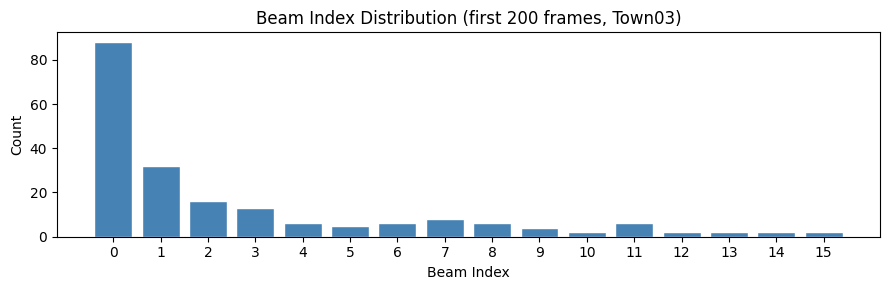

In [16]:
# ── Sample-level label distribution across N frames ──────────────────
N_SAMPLE = 200   # how many .npz files to scan for quick stats

beam_list = []
with zipfile.ZipFile(CHANNEL_ZIP, "r") as z:
    npz_files_scan = [f for f in z.namelist() if f.endswith("_paths.npz")][:N_SAMPLE]
    for fname in npz_files_scan:
        raw = z.read(fname)
        npz_s = np.load(io.BytesIO(raw))
        a_s = np.squeeze(npz_s["a"])
        if a_s.ndim == 2:
            a_s = a_s[:, :, np.newaxis]
        tx_p = np.sum(np.abs(a_s) ** 2, axis=(0, 2))
        beam_list.append(int(np.argmax(tx_p)))

beam_arr = np.array(beam_list)
counts = np.bincount(beam_arr, minlength=16)
print(f"Beam distribution over {len(beam_arr)} frames:")
for i, c in enumerate(counts):
    bar = "█" * int(c / max(counts) * 30)
    print(f"  Beam {i:2d} | {c:4d} | {bar}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(16), counts, color="steelblue", edgecolor="white")
ax.set_xlabel("Beam Index")
ax.set_ylabel("Count")
ax.set_title(f"Beam Index Distribution (first {len(beam_arr)} frames, Town03)")
ax.set_xticks(range(16))
plt.tight_layout()
plt.show()


## 1. Imports & Reproducibility

In [17]:
import numpy as np
import random
import os
import re
import io
import zipfile
import pickle
import hashlib
import time
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path, PurePosixPath
from typing import Dict, List, Optional, Sequence, Tuple, Union

import flwr as fl
import ray
import tensorflow as tf
from tensorflow import keras
import pandas as pd

# ── Reproducibility ───────────────────────────────────────────────────
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = str(seed)
tf.keras.backend.clear_session()

results_dir = "experiment_results"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print("Random seeds set. TF version:", tf.__version__)


Random seeds set. TF version: 2.19.1


## 2. Configuration

In [18]:
CFG = {
    # Training
    "local_epochs"   : 1,        # 1 epoch/round prevents client drift in FedAvg
    "lr"             : 5e-4,     # slower local updates → stabler global convergence
    "batch_size"     : 64,       # Mini-batch size (needed for 800-1300 samples/client)
    "grad_clip_norm" : 5.0,

    # Federated
    "client_frac"    : 1.0,      # Fit/evaluate ALL clients each round

    # Codebook
    # Paper uses Nt=64, Q=64. Our dataset has Nt=16, so Q_tx=16 avoids aliasing.
    # With Nt=16 and Q=64, multiple DFT beams are indistinguishable → mode collapse.
    "Q_tx"           : 16,   # Tx DFT beams = Nt (no oversampling)
    "Q_rx"           : 16,   # Rx DFT beams = Nr

    # Loss fixes for imbalanced binary heads and beam mode collapse
    "pos_weight_los"    : 10.0,  # was 4.5 — 84% NLOS imbalance needs stronger correction
    "pos_weight_change" : 10.0,  # was 5.0 — FedAvg averaging dilutes pos_weight signal
    "label_smoothing"   : 0.15,  # was 0.1 — stronger beam diversity pressure
}

# ── Dynamic client control ────────────────────────────────────────────────────
# Set to an int (e.g. MAX_CLIENTS = 10) to limit the number of client
# trajectories used in both the channel-only and multimodal FL runs.
# This also limits how much data is preloaded during multimodal training,
# making quick experiments much faster.
# Set to None to use all available trajectories.
MAX_CLIENTS = 10

print(f'CFG: {CFG}')
print(f'MAX_CLIENTS: {MAX_CLIENTS}  (None = use all)')


CFG: {'local_epochs': 1, 'lr': 0.0005, 'batch_size': 64, 'grad_clip_norm': 5.0, 'client_frac': 1.0, 'Q_tx': 16, 'Q_rx': 16, 'pos_weight_los': 10.0, 'pos_weight_change': 10.0, 'label_smoothing': 0.15}
MAX_CLIENTS: 10  (None = use all)


## 3. Dataset

In [19]:
def _parse_total_antennas(config_name: str, side: str) -> int:
    m = re.search(rf"{side}_(\d+)_(\d+)", config_name)
    if not m:
        raise ValueError(f"Could not parse {side} from: {config_name}")
    return int(m.group(1)) * int(m.group(2))


def _safe_isfinite(x: np.ndarray) -> bool:
    if np.iscomplexobj(x):
        return np.isfinite(x.real).all() and np.isfinite(x.imag).all()
    return np.isfinite(x).all()


@dataclass(frozen=True)
class ChannelSampleRef:
    zip_path: Path
    inner_npz: str


def generate_dft_codebook(size: int, num_beams: int) -> np.ndarray:
    """
    DFT steering-vector codebook  (MMW paper Eq. 2 / Eq. 4).

    f(q)[n] = (1 / sqrt(Nt)) * exp(j * 2*pi / Q * n * q)

    Parameters
    ----------
    size      : Nt  – number of Tx antennas
    num_beams : Q   – number of DFT beams (paper uses Q=64)

    Returns
    -------
    codebook : complex64 array of shape (size, num_beams)
               Column q is the steering vector for beam q.
    """
    n = np.arange(size).reshape(-1, 1)
    q = np.arange(num_beams).reshape(1, -1)
    codebook = (1.0 / np.sqrt(size)) * np.exp(
        1j * (2 * np.pi / num_beams) * n * q
    )
    return codebook.astype(np.complex64)


# Sensor frame constants
# LiDAR reduced 512→128 pts: 4× lower RAM; sufficient for A2G spatial coverage.
_N_LIDAR_PTS = 128
_IMU_DIM     = 7   # acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, compass

print("Dataset helpers defined.")
print(f"Sensor constants: _N_LIDAR_PTS={_N_LIDAR_PTS}, _IMU_DIM={_IMU_DIM}")

Dataset helpers defined.
Sensor constants: _N_LIDAR_PTS=128, _IMU_DIM=7


In [20]:
# Cell: ChannelDataset class (multi-weather, multi-town, all CAVs)
class ChannelDataset:
    """
    Channel-only dataset aligned with MMW paper methodology.
    Supports loading from MULTIPLE weather conditions and towns.

    Feature: Effective channel H = sum_paths(a), shape (Nr, Nt)
             stacked as [real(H), imag(H), |H|]  -> (Nr, Nt, 3)

    Labels (multi-task):
        beam_index : int   — argmax exhaustive beam search (paper Eq. 4)
        g_opt      : float — peak achievable beamforming gain (channel quality)
        los        : int   — 1 = LoS, 0 = NLoS (from NPZ or power-ratio heuristic)
        H_complex  : complex64 (Nr, Nt)
    """

    # Known path variants for different weather conditions
    CHANNEL_PATH_VARIANTS = [
        "Channel Data/V2I",   # sunny layout
        "Channel Data",       # foggy layout (no V2I subdirectory)
    ]

    def __init__(
        self,
        root: Union[str, Path],
        config_name: str,
        Q_tx: int = 16,
        Q_rx: int = 16,
        weather_conditions: Optional[Sequence[str]] = None,
        towns: Optional[Sequence[str]] = None,
        scenario_contains: Optional[str] = None,
        cav_contains: Optional[str] = None,
        stride: int = 1,
        assert_no_nans: bool = True,
        assert_shapes: bool = True,
    ):
        self.root = Path(root)
        self.config_name = config_name

        if weather_conditions is None:
            weather_conditions = ["sunny"]
        self.weather_conditions = list(weather_conditions)

        self.config_dirs = []
        for weather in self.weather_conditions:
            found = False
            for variant in self.CHANNEL_PATH_VARIANTS:
                cdir = self.root / weather / variant / config_name
                if cdir.exists():
                    self.config_dirs.append(cdir)
                    print(f"  [OK] Found channel data: {weather} → {cdir}")
                    found = True
                    break
            if not found:
                print(f"  [WARN] No channel data for '{weather}' — skipped")
        if not self.config_dirs:
            raise FileNotFoundError(
                f"No channel data found for any weather condition: {self.weather_conditions}"
            )

        self.nt = _parse_total_antennas(config_name, "Nt")
        self.nr = _parse_total_antennas(config_name, "Nr")
        self.Q_tx = Q_tx
        self.Q_rx = Q_rx

        self.towns = list(towns) if towns else None
        self.scenario_contains = scenario_contains
        self.cav_contains = cav_contains
        self.stride = max(1, int(stride))
        self.assert_no_nans = assert_no_nans
        self.assert_shapes = assert_shapes

        # DFT codebooks (paper Eq. 2)
        self.tx_codebook = generate_dft_codebook(self.nt, Q_tx)  # (Nt, Q_tx)
        self.rx_codebook = generate_dft_codebook(self.nr, Q_rx)  # (Nr, Q_rx)

        self.index: List[ChannelSampleRef] = self._build_index()
        if self.stride > 1:
            self.index = self.index[::self.stride]

        self._expected_csi_shape: Optional[Tuple[int, ...]] = None

    # -- Index building -------------------------------------------------------
    def _build_index(self) -> List[ChannelSampleRef]:
        refs: List[ChannelSampleRef] = []

        for config_dir in self.config_dirs:
            if self.towns is None:
                zips = sorted(config_dir.glob("Town*.zip"))
            else:
                zips = [config_dir / f"{t}.zip" for t in self.towns]

            for zp in zips:
                if not zp.exists():
                    continue
                with zipfile.ZipFile(zp, "r") as z:
                    for name in z.namelist():
                        if not name.endswith("_paths.npz"):
                            continue
                        p = PurePosixPath(name)
                        if self.scenario_contains and self.scenario_contains.lower() not in str(p).lower():
                            continue
                        if self.cav_contains and self.cav_contains.lower() not in str(p).lower():
                            continue
                        refs.append(ChannelSampleRef(zip_path=zp, inner_npz=name))

        def sort_key(ref: ChannelSampleRef):
            p = PurePosixPath(ref.inner_npz)
            m = re.match(r"(\d+)_paths$", p.stem)
            return (str(ref.zip_path), str(p.parent), int(m.group(1)) if m else -1)

        refs.sort(key=sort_key)
        if not refs:
            raise ValueError(
                f"No *_paths.npz found under config dirs: {self.config_dirs}"
            )
        return refs

    # -- Metadata --------------------------------------------------------------
    def _parse_metadata(self, inner_path: str) -> Dict[str, str]:
        p = PurePosixPath(inner_path)
        m = re.match(r"(\d+)_paths\.npz$", p.name)
        frame_id = int(m.group(1)) if m else -1
        cav_id = p.parent.name if "cav" in p.parent.name.lower() else "unknown"
        location = p.parent.parent.name or "unknown"
        return {"location": location, "cav_id": cav_id, "frame_id": frame_id}

    def get_sample_metadata(self, idx: int) -> Dict[str, str]:
        ref = self.index[idx]
        meta = self._parse_metadata(ref.inner_npz)
        meta["town"] = ref.zip_path.stem
        meta["zip_path"] = str(ref.zip_path)
        meta["inner_path"] = ref.inner_npz
        for weather in self.weather_conditions:
            if weather in str(ref.zip_path):
                meta["weather"] = weather
                break
        else:
            meta["weather"] = "unknown"
        return meta

    def build_metadata_index(self) -> pd.DataFrame:
        rows = []
        for idx in range(len(self)):
            meta = self.get_sample_metadata(idx)
            meta["sample_idx"] = idx
            rows.append(meta)
        return pd.DataFrame(rows)

    # -- Core loading ----------------------------------------------------------
    def __len__(self) -> int:
        return len(self.index)

    def _load_npz(self, ref: ChannelSampleRef) -> Dict[str, np.ndarray]:
        with zipfile.ZipFile(ref.zip_path, "r") as z:
            raw = z.read(ref.inner_npz)
        npz = np.load(io.BytesIO(raw))
        return {k: npz[k] for k in npz.files}

    def _extract_csi(self, arrays: Dict[str, np.ndarray]) -> np.ndarray:
        """
        Effective channel matrix as model input.
        Returns (Nr, Nt, 3) float32: [real(H), imag(H), |H|]
        """
        a = arrays["a"]
        if self.assert_no_nans:
            assert _safe_isfinite(a), "Non-finite values in 'a'"

        a_sq = np.squeeze(a).astype(np.complex64)
        if a_sq.ndim == 2:
            a_sq = a_sq[:, :, np.newaxis]
        if a_sq.ndim != 3:
            raise ValueError(f"Unexpected squeezed 'a' shape: {a_sq.shape}")

        H = np.sum(a_sq, axis=2)  # (Nr, Nt) complex64
        csi = np.stack([H.real, H.imag, np.abs(H)], axis=-1).astype(np.float32)

        if self.assert_no_nans:
            assert _safe_isfinite(csi), "Non-finite in csi"
        return csi

    def compute_beam_index(self, a_sq: np.ndarray) -> Tuple[int, float, np.ndarray]:
        """
        Exhaustive beam search (paper Eq. 4).
        Returns (beam_idx, g_opt, H) where g_opt = peak achievable gain.
        """
        H = np.sum(a_sq.astype(np.complex64), axis=2)  # (Nr, Nt)
        response = self.rx_codebook.conj().T @ H @ self.tx_codebook  # (Q_rx, Q_tx)
        gain_per_tx = np.max(np.abs(response) ** 2, axis=0)  # (Q_tx,)
        g_opt = float(gain_per_tx.max())
        return int(np.argmax(gain_per_tx)), g_opt, H

    def __getitem__(self, idx: int) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
        ref = self.index[idx]
        arrays = self._load_npz(ref)

        a_sq = np.squeeze(arrays["a"]).astype(np.complex64)
        if a_sq.ndim == 2:
            a_sq = a_sq[:, :, np.newaxis]

        csi_tensor = self._extract_csi(arrays)

        if self.assert_shapes:
            if self._expected_csi_shape is None:
                self._expected_csi_shape = tuple(csi_tensor.shape)
            else:
                assert tuple(csi_tensor.shape) == self._expected_csi_shape, (
                    f"CSI shape mismatch: {self._expected_csi_shape} vs {csi_tensor.shape}"
                )

        beam_idx, g_opt, H = self.compute_beam_index(a_sq)

        # LoS: read from NPZ if present; else estimate from dominant-path power ratio
        _los_raw = arrays.get("los", None)
        if _los_raw is not None:
            los = int(np.squeeze(_los_raw).flat[0])
        else:
            path_power  = np.sum(np.abs(a_sq) ** 2, axis=(0, 1))
            total_power = path_power.sum() + 1e-12
            los = 1 if (path_power.max() / total_power) > 0.85 else 0

        labels = {
            "beam_index": np.array(beam_idx, dtype=np.int64),
            "g_opt"     : np.array(g_opt,     dtype=np.float32),
            "los"       : np.array(los,        dtype=np.int32),
            "H_complex" : H,
        }

        return csi_tensor, labels


In [21]:
# ── SensorIndex + load_sensor_frame + MultimodalChannelDataset ────────────────
# Modalities: CSI + LiDAR-512 + IMU  (RGB and GPS dropped)
import yaml
import struct

# ---------------------------------------------------------------------------
#  SensorIndex — discovers sensor zips and resolves channel→sensor alignment
# ---------------------------------------------------------------------------

SENSOR_PATH_VARIANTS = [
    "Sensor Data",
]

@dataclass
class SensorZipEntry:
    """One sensor .zip  (e.g. Town03_Tjunction_wiz_slope_seed42.zip)."""
    zip_path: Path
    scenario_prefix: str        # e.g. "Town03_Tjunction_wiz_slope_seed42"
    channel_location: str       # e.g. "Town03_Tjunction"  (prefix match)
    town: str                   # e.g. "Town03"


class SensorIndex:
    """
    Maps  (weather, channel_inner_npz)  →  (SensorZipEntry, cav_id, frame_id)
    so that MultimodalChannelDataset can look up the sensor zip for every
    channel sample.
    """

    def __init__(self, root: Union[str, Path],
                 weather_conditions: Sequence[str],
                 towns: Sequence[str]):
        self.root = Path(root)
        # key = (weather, channel_location, town)  →  SensorZipEntry
        self._map: Dict[Tuple[str, str, str], SensorZipEntry] = {}
        self._build(weather_conditions, towns)

    # ── build ----------------------------------------------------------------
    def _build(self, weathers, towns):
        for weather in weathers:
            for variant in SENSOR_PATH_VARIANTS:
                for town in towns:
                    sensor_dir = self.root / weather / variant / town
                    if not sensor_dir.exists():
                        continue
                    for zp in sorted(sensor_dir.glob("*.zip")):
                        stem = zp.stem  # e.g. Town03_Tjunction_wiz_slope_seed42
                        # derive the channel_location by stripping everything
                        # after the town-specific location tag.
                        # Channel uses e.g. "Town03_Tjunction"
                        # Sensor zip is    "Town03_Tjunction_wiz_slope_seed42"
                        ch_loc = self._stem_to_channel_location(stem, town)
                        entry = SensorZipEntry(
                            zip_path=zp,
                            scenario_prefix=stem,
                            channel_location=ch_loc,
                            town=town,
                        )
                        key = (weather, ch_loc, town)
                        self._map[key] = entry
        n = len(self._map)
        print(f"[SensorIndex] {n} sensor zips indexed")

    @staticmethod
    def _stem_to_channel_location(stem: str, town: str) -> str:
        """
        Town03_Tjunction_wiz_slope_seed42  →  Town03_Tjunction
        Town03_5wayroad_seed28             →  Town03_5wayroad
        Heuristic: the channel location = town + '_' + next word.
        """
        # Remove the town prefix to isolate the location part
        rest = stem[len(town) + 1:]  # "Tjunction_wiz_slope_seed42"
        # Take everything up to the first _seed or _wiz or similar suffix
        # Strategy: split on '_' and take parts until we hit a known suffix
        parts = rest.split("_")
        loc_parts = []
        stop_words = {"wiz", "seed", "slope"}
        for p in parts:
            if p.lower() in stop_words or re.match(r"seed\d+", p.lower()):
                break
            loc_parts.append(p)
        location = "_".join(loc_parts)  # "Tjunction" or "5wayroad" etc.
        return f"{town}_{location}"

    # ── resolve ---------------------------------------------------------------
    def resolve(self, weather: str, channel_inner_npz: str):
        """
        Given a channel inner path like
            Town03/Town03_Tjunction/cav_1/004276_paths.npz
        return (SensorZipEntry, cav_id, frame_id) or None.
        """
        p = PurePosixPath(channel_inner_npz)
        # parts: ('Town03', 'Town03_Tjunction', 'cav_1', '004276_paths.npz')
        if len(p.parts) < 4:
            return None
        town = p.parts[0]
        ch_location = p.parts[1]
        cav_id = p.parts[2]
        m = re.match(r"(\d+)_paths\.npz$", p.parts[3])
        if not m:
            return None
        frame_id = m.group(1)   # string like "004276"

        key = (weather, ch_location, town)
        entry = self._map.get(key)
        if entry is None:
            return None
        return (entry, cav_id, frame_id)


# ---------------------------------------------------------------------------
#  load_sensor_frame — reads LiDAR + IMU from a sensor zip
# ---------------------------------------------------------------------------

def _read_pcd_xyz(raw_bytes: bytes) -> np.ndarray:
    """Parse ASCII PCD → (N, 3) float32 (only xyz, ignore rgb)."""
    lines = raw_bytes.split(b"\n")
    header_end = 0
    n_points = 0
    for i, line in enumerate(lines):
        text = line.decode(errors="replace").strip()
        if text.startswith("POINTS"):
            n_points = int(text.split()[1])
        if text == "DATA ascii":
            header_end = i + 1
            break
    pts = []
    for line in lines[header_end: header_end + n_points]:
        parts = line.split()
        if len(parts) >= 3:
            pts.append([float(parts[0]), float(parts[1]), float(parts[2])])
    return np.array(pts, dtype=np.float32) if pts else np.zeros((0, 3), np.float32)


def load_sensor_frame(
    entry: SensorZipEntry,
    cav_id: str,
    frame_id: str,
    n_lidar_pts: int = _N_LIDAR_PTS,
    rng: np.random.Generator = None,
) -> Dict[str, np.ndarray]:
    """
    Load LiDAR and IMU from a sensor zip.

    Sensor zip layout:
        <scenario>/<cav_id>/<frame_id>.pcd   → LiDAR point cloud
        <scenario>/<cav_id>/<frame_id>.yaml  → IMU (imu_measurement section)

    Returns
    -------
    {"lidar": (n_lidar_pts, 3) float32, "imu": (7,) float32}
    IMU layout: [acc_x/g, acc_y/g, acc_z/g, gyro_x, gyro_y, gyro_z, compass/360]
    """
    if rng is None:
        rng = np.random.default_rng(42)

    prefix = f"{entry.scenario_prefix}/{cav_id}/{frame_id}"

    with zipfile.ZipFile(entry.zip_path, "r") as z:
        # ── LiDAR ────────────────────────────────────────────────────
        pcd_raw = z.read(f"{prefix}.pcd")
        pts = _read_pcd_xyz(pcd_raw)
        if len(pts) == 0:
            pts = np.zeros((1, 3), np.float32)
        # Sub-sample or pad to fixed size
        if len(pts) >= n_lidar_pts:
            idx = rng.choice(len(pts), n_lidar_pts, replace=False)
            pts = pts[idx]
        else:
            pad = np.zeros((n_lidar_pts - len(pts), 3), np.float32)
            pts = np.concatenate([pts, pad], axis=0)
        # Normalize to zero-mean per axis
        mean = pts.mean(axis=0, keepdims=True)
        std  = pts.std(axis=0, keepdims=True) + 1e-8
        lidar = ((pts - mean) / std).astype(np.float32)

        # ── IMU (from YAML) ──────────────────────────────────────────
        yaml_raw  = z.read(f"{prefix}.yaml")
        meta      = yaml.safe_load(yaml_raw)
        imu_meta  = meta["sensors"]["imu_measurement"]
        if imu_meta.get("data_missing", False):
            imu = np.zeros(_IMU_DIM, np.float32)
        else:
            acc  = imu_meta["accelerometer"]
            gyro = imu_meta["gyroscope"]
            comp = float(imu_meta.get("compass", 0.0))
            imu  = np.array([
                acc["x"]  / 9.81,  acc["y"]  / 9.81,  acc["z"]  / 9.81,
                gyro["x"],         gyro["y"],          gyro["z"],
                comp / 360.0,
            ], dtype=np.float32)

    return {"lidar": lidar, "imu": imu}


# ---------------------------------------------------------------------------
#  MultimodalChannelDataset
# ---------------------------------------------------------------------------
class MultimodalChannelDataset:
    """
    Aligns channel samples with their sensor observations.

    __getitem__ returns:
        csi    : (Nr, Nt, 3)          float32
        lidar  : (_N_LIDAR_PTS, 3)    float32  normalised xyz  (512 pts)
        imu    : (_IMU_DIM,)          float32  [acc/g ×3, gyro ×3, compass/360]
        labels : {"beam_index": int64, "H_complex": complex64 (Nr,Nt)}
    """

    def __init__(
        self,
        channel_dataset: "ChannelDataset",
        sensor_index: SensorIndex,
        n_lidar_pts: int = _N_LIDAR_PTS,
        seed: int = 42,
    ):
        self.channel_ds  = channel_dataset
        self.sensor_idx  = sensor_index
        self.n_lidar_pts = n_lidar_pts
        self._rng        = np.random.default_rng(seed)

        self._sensor_map = self._build_sensor_map()
        matched = sum(1 for v in self._sensor_map if v is not None)
        print(f"[MultimodalDataset] {len(self)} samples  |"
              f"  sensor-aligned: {matched}  |"
              f"  fallback (zeros): {len(self) - matched}")

    def _build_sensor_map(self):
        mapping = []
        for idx in range(len(self.channel_ds)):
            ref  = self.channel_ds.index[idx]
            meta = self.channel_ds.get_sample_metadata(idx)
            weather = meta.get("weather", "sunny")
            resolved = self.sensor_idx.resolve(weather, ref.inner_npz)
            mapping.append(resolved)
        return mapping

    def __len__(self):
        return len(self.channel_ds)

    def __getitem__(self, idx: int):
        csi, labels = self.channel_ds[idx]

        resolved = self._sensor_map[idx]
        if resolved is not None:
            entry, cav_id, frame_id = resolved
            try:
                sensor = load_sensor_frame(
                    entry, cav_id, frame_id,
                    n_lidar_pts=self.n_lidar_pts,
                    rng=self._rng,
                )
                lidar = sensor["lidar"]
                imu   = sensor["imu"]
            except Exception:
                lidar, imu = self._zeros()
        else:
            lidar, imu = self._zeros()

        return csi, lidar, imu, labels

    def _zeros(self):
        lidar = np.zeros((self.n_lidar_pts, 3), np.float32)
        imu   = np.zeros(_IMU_DIM, np.float32)
        return lidar, imu

    @property
    def tx_codebook(self): return self.channel_ds.tx_codebook
    @property
    def rx_codebook(self): return self.channel_ds.rx_codebook
    @property
    def nr(self): return self.channel_ds.nr
    @property
    def nt(self): return self.channel_ds.nt


print("SensorIndex, load_sensor_frame, MultimodalChannelDataset defined.")

SensorIndex, load_sensor_frame, MultimodalChannelDataset defined.


In [22]:
# -- Methodology Sanity Check --------------------------------------------------
# Verify DFT codebooks, beam selection, and normalized gain.
import numpy as np

Q_tx, Q_rx, Nt, Nr = 64, 16, 16, 16

# 1. Codebooks
tx_cb = generate_dft_codebook(Nt, Q_tx)  # (16, 64)
rx_cb = generate_dft_codebook(Nr, Q_rx)  # (16, 16)
assert tx_cb.shape == (Nt, Q_tx)
assert rx_cb.shape == (Nr, Q_rx)

# Rx codebook is square DFT -> should be unitary
gram_rx = rx_cb.conj().T @ rx_cb
assert np.allclose(gram_rx, np.eye(Q_rx), atol=1e-4), "Rx codebook not unitary"
print(f"Tx codebook: {tx_cb.shape} (Nt={Nt}, Q_tx={Q_tx})")
print(f"Rx codebook: {rx_cb.shape} (Nr={Nr}, Q_rx={Q_rx}, unitary)")

# 2. Simulate exhaustive beam search (Eq. 4)
rng = np.random.default_rng(42)
n_paths = 8
a_fake = (rng.standard_normal((Nr, Nt, n_paths))
        + 1j * rng.standard_normal((Nr, Nt, n_paths))).astype(np.complex64)
H = np.sum(a_fake, axis=2)  # (Nr, Nt)

response = rx_cb.conj().T @ H @ tx_cb  # (Q_rx, Q_tx)
gain_per_tx = np.max(np.abs(response)**2, axis=0)
beam_idx = int(np.argmax(gain_per_tx))
assert 0 <= beam_idx < Q_tx
print(f"Beam index: {beam_idx} (range 0-{Q_tx-1})")

# 3. Normalized gain (Eq. 3)
optimal_gain = np.max(np.abs(response)**2)
achieved_gain = gain_per_tx[beam_idx]
norm_gain = achieved_gain / (optimal_gain + 1e-12)
print(f"Normalized gain: {norm_gain:.4f} (should be 1.0 for optimal)")
assert np.isclose(norm_gain, 1.0), "Optimal selection should give gain=1.0"

# 4. Feature tensor shape (with geometric features)
# Simulate geometric features
tau_mean = 1e-7
theta_mean = np.pi/2
phi_mean = np.pi/4
tau_grid = np.full((Nr, Nt), tau_mean, dtype=np.float32)
theta_grid = np.full((Nr, Nt), theta_mean, dtype=np.float32)
phi_grid = np.full((Nr, Nt), phi_mean, dtype=np.float32)

csi = np.stack([H.real, H.imag, np.abs(H), tau_grid, theta_grid, phi_grid], axis=-1).astype(np.float32)
assert csi.shape == (Nr, Nt, 6)
print(f"CSI feature shape: {csi.shape}  [real(H), imag(H), |H|, tau, theta_t, phi_t]")

print("\nAll checks passed.")


Tx codebook: (16, 64) (Nt=16, Q_tx=64)
Rx codebook: (16, 16) (Nr=16, Q_rx=16, unitary)
Beam index: 23 (range 0-63)
Normalized gain: 1.0000 (should be 1.0 for optimal)
CSI feature shape: (16, 16, 6)  [real(H), imag(H), |H|, tau, theta_t, phi_t]

All checks passed.


In [23]:
class DatasetSplitter:
    """Trajectory-aware train/test splitting (1 client = 1 CAV trajectory)."""

    def __init__(self, dataset: ChannelDataset):
        self.dataset = dataset
        self.metadata_df = dataset.build_metadata_index()
        print(f"Metadata index built: {len(self.metadata_df)} samples")
        # Summary stats
        n_towns = self.metadata_df["town"].nunique()
        n_weather = self.metadata_df["weather"].nunique() if "weather" in self.metadata_df.columns else 1
        print(f"  Towns: {n_towns}, Weather conditions: {n_weather}")

    def get_trajectory_groups(self) -> Dict[str, List[int]]:
        trajectories = {}
        # Group by weather + town + location + cav for unique trajectories
        group_cols = ["town", "location", "cav_id"]
        if "weather" in self.metadata_df.columns:
            group_cols = ["weather"] + group_cols

        for keys, group in self.metadata_df.groupby(group_cols):
            if isinstance(keys, tuple):
                traj_id = "_".join(str(k) for k in keys)
            else:
                traj_id = str(keys)
            trajectories[traj_id] = group.sort_values("frame_id")["sample_idx"].tolist()
        return trajectories

    def split_trajectory_temporal(
        self, indices: List[int], train_ratio: float = 0.7
    ) -> Tuple[List[int], List[int]]:
        """
        Temporal split: first 70% → train, last 30% → test.
        Tests generalization to new positions along trajectory.
        """
        split = int(len(indices) * train_ratio)
        return indices[:split], indices[split:]

    def split_trajectory_random(
        self, indices: List[int], train_ratio: float = 0.7, seed: int = 42
    ) -> Tuple[List[int], List[int]]:
        """
        Random split: shuffle then split 70/30.
        Tests generalization to unseen samples from SAME distribution.
        """
        rng = np.random.RandomState(seed)
        shuffled = np.array(indices.copy())
        rng.shuffle(shuffled)
        split = int(len(shuffled) * train_ratio)
        return shuffled[:split].tolist(), shuffled[split:].tolist()


@dataclass
class ChannelClientData:
    train_indices: List[int]
    test_indices: List[int]
    client_id: int
    trajectory_id: str


def build_clients(
    dataset: ChannelDataset,
    train_ratio: float = 0.7,
    min_trajectory_length: int = 10,
    split_strategy: str = "temporal",  # "temporal" or "random"
) -> Tuple[List[ChannelClientData], Dict[str, List[int]]]:
    """
    Build federated clients from trajectory data.

    Returns
    -------
    clients      : list of ChannelClientData (one per trajectory)
    trajectories : the full trajectory dict — reuse in precompute_beam_changes
                   to avoid rebuilding DatasetSplitter a second time.

    Args:
        split_strategy:
            - "temporal": first 70% train, last 30% test
            - "random"  : random 70/30 split
    """
    splitter = DatasetSplitter(dataset)
    trajectories = splitter.get_trajectory_groups()
    print(f"Total trajectories: {len(trajectories)}")

    trajectories = {
        t: idx for t, idx in trajectories.items() if len(idx) >= min_trajectory_length
    }
    print(f"After length filter (>={min_trajectory_length}): {len(trajectories)}")

    clients = []
    for cid, traj_id in enumerate(sorted(trajectories)):
        if split_strategy == "random":
            train_idx, test_idx = splitter.split_trajectory_random(
                trajectories[traj_id], train_ratio
            )
        else:  # temporal
            train_idx, test_idx = splitter.split_trajectory_temporal(
                trajectories[traj_id], train_ratio
            )
        if not train_idx or not test_idx:
            continue
        clients.append(
            ChannelClientData(train_idx, test_idx, cid, traj_id)
        )

    total_train = sum(len(c.train_indices) for c in clients)
    total_test = sum(len(c.test_indices) for c in clients)
    print(f"\nClients created: {len(clients)} (split_strategy={split_strategy})")
    print(f"Total train samples: {total_train}")
    print(f"Total test samples:  {total_test}")
    print(f"Avg samples per client: {(total_train + total_test) / max(len(clients), 1):.0f}")
    return clients, trajectories

# ── Hierarchical Cluster Assignment ──────────────────────────────────────────
TOWN_ORDER = ["Town03", "Town05", "Town07", "Town10"]


def _client_sort_key(c: ChannelClientData):
    """Sort key: (town_rank, location, weather, cav_id) from trajectory_id."""
    parts    = c.trajectory_id.split("_")
    weather  = parts[0]
    town     = parts[1]
    location = "_".join(parts[2:-1])
    cav_id   = parts[-1]
    return (TOWN_ORDER.index(town) if town in TOWN_ORDER else 99,
            location, weather, cav_id)


def build_clusters(clients: List[ChannelClientData], n_clusters: int = 3
                   ) -> Dict[int, List[int]]:
    """
    Assign FL clients to n_clusters equal-size geographic clusters for
    hierarchical aggregation (Cluster Head model).

    Clients are sorted by (town_rank, location, weather, cav_id) to produce
    a town-ordered list, then divided into n_clusters equal thirds.
    This guarantees equal cluster sizes regardless of per-town location counts.

    Communication design (3 clusters):
        CH0  — Cluster 0 intra-cluster aggregate         (Town03-heavy)
        CH1  — Cluster 1 intra-cluster aggregate          (Town05/07 boundary)
               + global aggregator: receives from CH0 and CH2
        CH2  — Cluster 2 intra-cluster aggregate         (Town10-heavy)

    Returns
    -------
    cluster_map : Dict[cluster_id -> List[client_index]]
        client_index = 0-based position in the original `clients` list.
    """
    sorted_indices = sorted(range(len(clients)), key=lambda i: _client_sort_key(clients[i]))
    N      = len(sorted_indices)
    thirds = [N // n_clusters + (1 if i < N % n_clusters else 0)
              for i in range(n_clusters)]

    cluster_map: Dict[int, List[int]] = {}
    start = 0
    for cid, size in enumerate(thirds):
        cluster_map[cid] = sorted_indices[start : start + size]
        start += size

    # Print summary
    for cid, idxs in cluster_map.items():
        towns_in = [clients[i].trajectory_id.split("_")[1] for i in idxs]
        counts   = {t: towns_in.count(t) for t in TOWN_ORDER if t in towns_in}
        print(f"  Cluster {cid} (CH{cid}): {len(idxs)} clients — {counts}")

    return cluster_map


We group by the frames by town, location, cav_id

build trajectories like this

{
  "Town03_TJ_cav1": [0,1,2,...],
  "Town03_TJ_cav2": [...],
}

len(idx) >= min_trajectory_length (set to 10)

Then we assign each trajectory to one client as a CAV

In [24]:
# ── Cell: Load Dataset ── channel + multimodal + build clients ────────────────
tf.keras.backend.clear_session()

WEATHER_CONDITIONS = ["sunny", "foggy", "rainy"]
TOWNS = ["Town03", "Town05", "Town07", "Town10"]
DATA_ROOT = "/Users/sadmanrahin/Library/CloudStorage/GoogleDrive-saddyrahin2004@gmail.com/My Drive/Dataset"
#DATA_ROOT = "/content/drive/MyDrive/Dataset"
# 1. Channel-only dataset
ds = ChannelDataset(
    root=DATA_ROOT,
    config_name="Nt_1_16_Nr_1_16_fc_28GHz",
    weather_conditions=WEATHER_CONDITIONS,
    towns=TOWNS,
    stride=10,
    Q_tx=CFG["Q_tx"],
    Q_rx=CFG["Q_rx"],
)
print(f"\nChannel dataset: {len(ds)} samples  (stride=10, all towns)")
print(f"Config dirs: {len(ds.config_dirs)}")

x, y = ds[0]
print(f"CSI shape   : {x.shape}")
print(f"Beam index  : {y['beam_index']}  g_opt: {y['g_opt']:.4f}  los: {y['los']}")

# 2. Sensor index (for multimodal)
sensor_idx = SensorIndex(
    root=DATA_ROOT,
    weather_conditions=WEATHER_CONDITIONS,
    towns=TOWNS,
)

# 3. Multimodal dataset (wraps channel dataset + sensor index)
mm_ds = MultimodalChannelDataset(
    channel_dataset=ds,
    sensor_index=sensor_idx,
)

# 4. Build federated clients (trajectory-aware)
clients, _trajectories = build_clients(ds, train_ratio=0.7, min_trajectory_length=10, split_strategy="temporal")

# ── Cap number of clients if MAX_CLIENTS is set ───────────────────────────────
if MAX_CLIENTS is not None:
    clients = clients[:MAX_CLIENTS]
    print(f'\n  Capped to {len(clients)} clients (MAX_CLIENTS={MAX_CLIENTS})')

# ── Precompute beam_change labels ─────────────────────────────────────────────
# beam_change[i] = 1 if beam at frame i differs from the previous frame
# in the same trajectory (sorted by frame_id), else 0.
# This is a dataset-level property, computed once and passed to every client.

def precompute_beam_changes(
    channel_ds: ChannelDataset,
    clients: list,
    trajectories: dict,
) -> dict:
    """
    Compute beam-switch labels using batch ZIP reads.

    Groups all needed frame indices by ZIP file and opens each ZIP once,
    reading all frames from it in a single open/close cycle. Reduces Drive
    open() calls from O(n_frames) to O(n_zips), cutting wall time from
    ~450s to ~5-15s on Google Drive.

    Returns
    -------
    dict : {sample_idx (int) -> beam_change (int, 0 or 1)}
    """
    from collections import defaultdict
    print("Precomputing beam_change labels (batch ZIP reads)...")
    _t = time.time()

    # Build set of all client-used indices
    client_idx_set = set()
    for c in clients:
        client_idx_set.update(c.train_indices)
        client_idx_set.update(c.test_indices)

    # Collect ALL frame indices from relevant trajectories (needed for prev_beam continuity)
    needed_indices: set = set()
    for traj_id, indices in trajectories.items():
        if client_idx_set.intersection(indices):
            needed_indices.update(indices)

    # ── Pass 1: batch read beam_index, one ZIP open per file ─────────────────
    zip_groups = defaultdict(list)
    for idx in needed_indices:
        zip_groups[channel_ds.index[idx].zip_path].append(idx)

    beam_cache: dict = {}
    n_zips = len(zip_groups)
    for z_i, (zip_path, idx_list) in enumerate(zip_groups.items(), 1):
        with zipfile.ZipFile(zip_path, "r") as zf:
            for idx in idx_list:
                raw    = zf.read(channel_ds.index[idx].inner_npz)
                arrays = np.load(io.BytesIO(raw))
                a_sq   = np.squeeze(arrays["a"]).astype(np.complex64)
                if a_sq.ndim == 2:          # single-path frame: add path dim
                    a_sq = a_sq[:, :, np.newaxis]
                beam_idx, _, _ = channel_ds.compute_beam_index(a_sq)
                beam_cache[idx] = beam_idx
        print(f"  ZIP {z_i}/{n_zips}: {zip_path.name} ({len(idx_list)} frames)")

    # ── Pass 2: compute beam_change per trajectory from cache (no I/O) ───────
    changes: dict = {}
    for traj_id, indices in trajectories.items():
        if not client_idx_set.intersection(indices):
            continue
        prev_beam = None
        for idx in indices:
            b = beam_cache.get(idx)
            if b is None:
                prev_beam = None   # gap in trajectory — reset continuity
                continue
            if idx in client_idx_set:
                changes[idx] = 0 if prev_beam is None else int(b != prev_beam)
            prev_beam = b

    # Fallback: any client index not reached gets 0
    for i in client_idx_set:
        changes.setdefault(i, 0)

    n_chg = sum(changes.values())
    print(f"  Done in {time.time()-_t:.1f}s — "
          f"{len(needed_indices)} frames across {n_zips} ZIPs | "
          f"beam transitions: {n_chg}/{len(changes)} ({100*n_chg/max(len(changes),1):.1f}%)")
    return changes

beam_changes_global = precompute_beam_changes(ds, clients, _trajectories)

# Quick label check
sample_n = min(500, len(ds))
beam_labels = [ds[i][1]["beam_index"].item() for i in range(sample_n)]
gopt_labels = [ds[i][1]["g_opt"].item()      for i in range(sample_n)]
los_labels  = [ds[i][1]["los"].item()        for i in range(sample_n)]
print(f"\nLabel summary (first {sample_n} samples):")
print(f"  beam_index : range [{min(beam_labels)}, {max(beam_labels)}]  "
      f"| unique={len(set(beam_labels))}")
print(f"  g_opt      : min={min(gopt_labels):.2f}  max={max(gopt_labels):.2f}  "
      f"mean={np.mean(gopt_labels):.2f}")
print(f"  los        : LoS={sum(los_labels)}/{sample_n}  "
      f"({100.0*sum(los_labels)/sample_n:.1f}%)")
print(f"  beam_change: transitions in global dict = {sum(beam_changes_global.values())}")
print(f"\nBeam distribution: {np.bincount(beam_labels, minlength=CFG['Q_tx'])}")

# ── Aliases used by the multimodal FL training cell ───────────────────────────
mm_channel_ds  = ds        # ChannelDataset — exposes .nr, .nt, .tx_codebook, etc.
mm_clients_raw = clients   # list[ChannelClientData] — same trajectory splits


  [OK] Found channel data: sunny → /Users/sadmanrahin/Library/CloudStorage/GoogleDrive-saddyrahin2004@gmail.com/My Drive/Dataset/sunny/Channel Data/V2I/Nt_1_16_Nr_1_16_fc_28GHz
  [OK] Found channel data: foggy → /Users/sadmanrahin/Library/CloudStorage/GoogleDrive-saddyrahin2004@gmail.com/My Drive/Dataset/foggy/Channel Data/Nt_1_16_Nr_1_16_fc_28GHz
  [OK] Found channel data: rainy → /Users/sadmanrahin/Library/CloudStorage/GoogleDrive-saddyrahin2004@gmail.com/My Drive/Dataset/rainy/Channel Data/V2I/Nt_1_16_Nr_1_16_fc_28GHz

Channel dataset: 12330 samples  (stride=10, all towns)
Config dirs: 3
CSI shape   : (16, 16, 3)
Beam index  : 8  g_opt: 0.0000  los: 0
[SensorIndex] 48 sensor zips indexed
[MultimodalDataset] 12330 samples  |  sensor-aligned: 11730  |  fallback (zeros): 600
Metadata index built: 12330 samples
  Towns: 4, Weather conditions: 3
Total trajectories: 116
After length filter (>=10): 116

Clients created: 116 (split_strategy=temporal)
Total train samples: 8631
Total test sam

## 7. Model Architecture (Beam Only)

Conv(32) = for edges

Conv(64) = for the shapes

Conv(128) = high level learning

BN -> normalize the extremes
Relu -> if it's insignificant, then remove it from the calculation

The Dense layer converts features space and provides insights from the conv layers

In [25]:
# ── Model Architecture ────────────────────────────────────────────────────────
#  1. ChannelEncoder        — CNN for CSI  (Nr, Nt, 3)
#  2. LiDAREncoder          — PointNet-style for LiDAR  (128, 3) [slimmed]
#  3. IMUEncoder            — GRU over 7 IMU components  (7,) → (7,1) sequence
#  4. CrossModalAttention   — multi-head attention fusion over 3 modalities
#  5. BeamModel             — channel-only multi-task head
#  6. MultimodalBeamModel   — full multimodal multi-task head
#
# Shared helper (avoids duplication across clients):
#   _compute_normalized_gain(H_batch, pred_indices, tx_cb, rx_cb) → float
# ──────────────────────────────────────────────────────────────────────────────

def _compute_normalized_gain(H_batch, pred_indices, tx_codebook, rx_codebook):
    """Mean normalised beamforming gain over a batch. Used by both clients."""
    gains = []
    for i in range(len(pred_indices)):
        H           = H_batch[i]
        resp        = rx_codebook.conj().T @ H @ tx_codebook
        gain_matrix = np.abs(resp) ** 2
        achieved    = np.max(gain_matrix[:, pred_indices[i]])
        optimal     = np.max(gain_matrix)
        gains.append(achieved / (optimal + 1e-12))
    return float(np.mean(gains))


@tf.keras.utils.register_keras_serializable()
class ChannelEncoder(tf.keras.Model):
    """CNN encoder for effective channel matrix. Input: (B, Nr, Nt, 3)."""
    def __init__(self, nr: int, nt: int, emb_dim: int = 128, dropout: float = 0.0, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = keras.layers.Conv2D(32,  3, padding="same", activation="relu")
        self.bn1   = keras.layers.BatchNormalization()
        self.conv2 = keras.layers.Conv2D(64,  3, padding="same", activation="relu")
        self.bn2   = keras.layers.BatchNormalization()
        self.conv3 = keras.layers.Conv2D(128, 3, padding="same", activation="relu")
        self.bn3   = keras.layers.BatchNormalization()
        self.gap   = keras.layers.GlobalAveragePooling2D()
        self.proj  = keras.Sequential([
            keras.layers.Dense(256, activation="relu"),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(emb_dim),
        ])

    def call(self, x, training=False):
        h = self.bn1(self.conv1(x), training=training)
        h = self.bn2(self.conv2(h), training=training)
        h = self.bn3(self.conv3(h), training=training)
        h = self.gap(h)
        return self.proj(h, training=training)


@tf.keras.utils.register_keras_serializable()
class LiDAREncoder(tf.keras.Model):
    """
    PointNet-style encoder for LiDAR point clouds.
    Input:  (B, 128, 3)  — xyz points (downsampled from 512)
    Output: (B, emb_dim)
    Channels halved (64→128→256 became 32→64→128) to match reduced point count.
    """
    def __init__(self, emb_dim: int = 128, dropout: float = 0.0, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = keras.layers.Conv1D(32,  1, activation="relu")
        self.bn1   = keras.layers.BatchNormalization()
        self.conv2 = keras.layers.Conv1D(64,  1, activation="relu")
        self.bn2   = keras.layers.BatchNormalization()
        self.conv3 = keras.layers.Conv1D(128, 1, activation="relu")
        self.bn3   = keras.layers.BatchNormalization()
        self.pool  = keras.layers.GlobalMaxPooling1D()
        self.proj  = keras.Sequential([
            keras.layers.Dense(emb_dim, activation="relu"),
            keras.layers.Dropout(dropout),
        ])

    def call(self, x, training=False):
        h = self.bn1(self.conv1(x), training=training)
        h = self.bn2(self.conv2(h), training=training)
        h = self.bn3(self.conv3(h), training=training)
        h = self.pool(h)
        return self.proj(h, training=training)


@tf.keras.utils.register_keras_serializable()
class IMUEncoder(tf.keras.Model):
    """
    GRU encoder for IMU vector (acc_xyz + gyro_xyz + compass = 7 values).
    Each IMU component is treated as one timestep of a 1-D sequence, so the
    GRU learns inter-component dependencies (e.g. acc→gyro coupling).
    Input:  (B, 7)  →  reshaped to  (B, 7, 1)
    Output: (B, emb_dim)
    Lightweight: GRU(32) uses ~4× fewer params than the previous Dense(64→128).
    """
    def __init__(self, emb_dim: int = 128, dropout: float = 0.0, **kwargs):
        super().__init__(**kwargs)
        self.gru  = keras.layers.GRU(32, return_sequences=False)
        self.proj = keras.Sequential([
            keras.layers.Dense(64, activation="relu"),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(emb_dim),
        ])

    def call(self, x, training=False):
        seq = tf.expand_dims(x, axis=-1)        # (B, 7) → (B, 7, 1)
        h   = self.gru(seq, training=training)  # (B, 32)
        return self.proj(h, training=training)


@tf.keras.utils.register_keras_serializable()
class CrossModalAttention(tf.keras.layers.Layer):
    """
    Multi-head attention over stacked modality embeddings.
    Input:  list of (B, emb_dim) tensors
    Output: (B, emb_dim) — attended fusion
    """
    def __init__(self, emb_dim: int = 128, n_heads: int = 4, **kwargs):
        super().__init__(**kwargs)
        self.mha  = keras.layers.MultiHeadAttention(
            num_heads=n_heads, key_dim=emb_dim // n_heads
        )
        self.norm = keras.layers.LayerNormalization()

    def call(self, embeddings, training=False):
        x        = tf.stack(embeddings, axis=1)      # (B, n_mod, emb_dim)
        attn_out = self.mha(x, x, training=training)
        x        = self.norm(x + attn_out)
        return tf.reduce_mean(x, axis=1)             # (B, emb_dim)


# ──────────────────────────────────────────────────────────────────────────────
# Channel-only multi-task model
# Predicts: beam_index | g_opt | los | beam_change
# ──────────────────────────────────────────────────────────────────────────────
@tf.keras.utils.register_keras_serializable()
class BeamModel(keras.Model):
    """
    Multi-task beam prediction — channel only.

    Outputs dict:
        'beam'        : (B, n_beams)  beam classification logits
        'gopt'        : (B,)          peak gain, z-score normalised (MSE)
        'los'         : (B,)          LoS/NLoS logit (binary)
        'beam_change' : (B,)          beam-switch logit (binary)
    """
    def __init__(self, nr: int, nt: int, beam_codebook_size: int,
                 dropout: float = 0.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = ChannelEncoder(nr, nt, emb_dim=128, dropout=dropout)
        self.shared  = keras.Sequential([
            keras.layers.Dense(256, activation="relu"),
            keras.layers.BatchNormalization(),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(128, activation="relu"),
        ])
        self.beam_head   = keras.layers.Dense(beam_codebook_size, name="beam")
        self.gopt_head   = keras.layers.Dense(1, name="gopt")
        self.los_head    = keras.layers.Dense(1, name="los")
        self.change_head = keras.layers.Dense(1, name="beam_change")

    def call(self, x, training=False):
        emb = self.encoder(x, training=training)
        h   = self.shared(emb, training=training)
        return {
            "beam"       : self.beam_head(h),
            "gopt"       : tf.squeeze(self.gopt_head(h),   axis=-1),
            "los"        : tf.squeeze(self.los_head(h),    axis=-1),
            "beam_change": tf.squeeze(self.change_head(h), axis=-1),
        }

    def build_model(self, nr, nt):
        _ = self(tf.random.normal((1, nr, nt, 3)), training=False)
        self.built = True


# ──────────────────────────────────────────────────────────────────────────────
# Multimodal multi-task model (CSI + LiDAR-128 + IMU-GRU)
# Same four task heads as BeamModel so both clients report identical metrics.
# ──────────────────────────────────────────────────────────────────────────────
@tf.keras.utils.register_keras_serializable()
class MultimodalBeamModel(keras.Model):
    """
    Multimodal beam prediction: CSI + LiDAR-128 + IMU(GRU).
    Cross-modal attention fuses per-modality embeddings before shared trunk.

    Outputs dict (same schema as BeamModel):
        'beam'        : (B, n_beams)
        'gopt'        : (B,)
        'los'         : (B,)
        'beam_change' : (B,)
    """
    def __init__(self, nr: int = 16, nt: int = 16, n_beams: int = 16,
                 emb_dim: int = 128, dropout: float = 0.1, **kwargs):
        super().__init__(**kwargs)
        self.csi_enc   = ChannelEncoder(nr, nt, emb_dim=emb_dim, dropout=dropout)
        self.lidar_enc = LiDAREncoder(emb_dim=emb_dim, dropout=dropout)
        self.imu_enc   = IMUEncoder(emb_dim=emb_dim, dropout=dropout)
        self.fusion    = CrossModalAttention(emb_dim=emb_dim)
        self.shared    = keras.Sequential([
            keras.layers.Dense(256, activation="relu"),
            keras.layers.BatchNormalization(),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(128, activation="relu"),
        ])
        self.beam_head   = keras.layers.Dense(n_beams, name="beam")
        self.gopt_head   = keras.layers.Dense(1, name="gopt")
        self.los_head    = keras.layers.Dense(1, name="los")
        self.change_head = keras.layers.Dense(1, name="beam_change")

    def call(self, csi, lidar, imu, training=False):
        e_csi   = self.csi_enc(csi,    training=training)
        e_lidar = self.lidar_enc(lidar, training=training)
        e_imu   = self.imu_enc(imu,    training=training)
        fused   = self.fusion([e_csi, e_lidar, e_imu], training=training)
        h       = self.shared(fused, training=training)
        return {
            "beam"       : self.beam_head(h),
            "gopt"       : tf.squeeze(self.gopt_head(h),   axis=-1),
            "los"        : tf.squeeze(self.los_head(h),    axis=-1),
            "beam_change": tf.squeeze(self.change_head(h), axis=-1),
        }

    def build_model(self, nr, nt, n_lidar=128):
        csi   = tf.random.normal((1, nr, nt, 3))
        lidar = tf.random.normal((1, n_lidar, 3))
        imu   = tf.random.normal((1, 7))
        _ = self(csi, lidar, imu, training=False)
        self.built = True


print("Models defined:")
print("  ChannelEncoder   — CNN 32→64→128 + GAP")
print("  LiDAREncoder     — PointNet 32→64→128 (128 pts, slimmed)")
print("  IMUEncoder       — GRU(32) over 7 IMU components [new]")
print("  CrossModalAttention — MHA fusion")
print("  BeamModel        — channel-only, 4 task heads")
print("  MultimodalBeamModel — CSI+LiDAR+IMU, 4 task heads [upgraded]")
print()
print("Shared helper: _compute_normalized_gain(H_batch, pred_indices, tx_cb, rx_cb)")

Models defined:
  ChannelEncoder   — CNN 32→64→128 + GAP
  LiDAREncoder     — PointNet 32→64→128 (128 pts, slimmed)
  IMUEncoder       — GRU(32) over 7 IMU components [new]
  CrossModalAttention — MHA fusion
  BeamModel        — channel-only, 4 task heads
  MultimodalBeamModel — CSI+LiDAR+IMU, 4 task heads [upgraded]

Shared helper: _compute_normalized_gain(H_batch, pred_indices, tx_cb, rx_cb)


## 8. Flower Client (Beam Only)

In [26]:
# ── BeamFlowerClient — multi-task federated client ────────────────────────────
#
# Jointly trains on four targets per CSI sample:
#   beam_index  — which Tx beam gives best gain (16-way CE, weight 1.0)
#   g_opt       — peak achievable channel gain, z-normalised (MSE, weight 0.3)
#   los         — Line-of-Sight flag (binary BCE, weight 0.2)
#   beam_change — did beam switch vs previous frame (binary BCE, weight 0.2)
#
# Total loss = 1.0·CE_beam + 0.3·MSE_gopt + 0.2·wBCE_los + 0.2·wBCE_change
# Beam CE uses label smoothing (cfg["label_smoothing"]) to prevent mode collapse.
# Binary heads use class-weighted BCE (cfg["pos_weight_*"]) for imbalanced labels.

class BeamFlowerClient(fl.client.NumPyClient):

    LOSS_WEIGHTS = {"beam": 1.0, "gopt": 1.0, "los": 0.5, "change": 0.5}

    def __init__(self, model, dataset, train_indices, test_indices,
                 cfg, trajectory_id, beam_changes: dict):
        self.model         = model
        self.dataset       = dataset
        self.train_indices = train_indices
        self.test_indices  = test_indices
        self.cfg           = cfg
        self.trajectory_id = trajectory_id
        self.beam_changes  = beam_changes
        self.optimizer     = keras.optimizers.Adam(cfg["lr"])
        self.grad_clip_norm = cfg.get("grad_clip_norm", 5.0)
        self.batch_size    = cfg.get("batch_size", 64)

        self._cache_train  = None
        self._cache_test   = None
        self._gopt_stats   = None

    def _load(self, indices, return_H=False, split="train"):
        """Load + cache data. Returns (X, beam, gopt_znorm, los, change [, H])."""
        if split == "train" and not return_H and self._cache_train is not None:
            return self._cache_train
        if split == "test" and self._cache_test is not None:
            cached = self._cache_test
            if (return_H and len(cached) == 6) or (not return_H and len(cached) == 5):
                return cached

        X, y_beam, y_gopt, y_los, y_change, Hs = [], [], [], [], [], []
        for i in indices:
            x, labels = self.dataset[i]
            X.append(x)
            y_beam.append(int(labels["beam_index"]))
            y_gopt.append(float(labels.get("g_opt", 1.0)))
            y_los.append(int(labels.get("los", 0)))
            y_change.append(int(self.beam_changes.get(i, 0)))
            if return_H:
                Hs.append(labels["H_complex"])

        X_arr = np.stack(X).astype(np.float32)
        mean  = X_arr.mean(axis=(1, 2), keepdims=True)
        std   = X_arr.std(axis=(1, 2),  keepdims=True) + 1e-8
        X_arr = (X_arr - mean) / std

        gopt_arr = np.array(y_gopt, dtype=np.float32)
        if split == "train":
            self._gopt_stats = (float(gopt_arr.mean()), float(gopt_arr.std()) + 1e-8)
        if self._gopt_stats is not None:
            gopt_arr = (gopt_arr - self._gopt_stats[0]) / self._gopt_stats[1]

        result = (
            X_arr,
            np.array(y_beam,   dtype=np.int32),
            gopt_arr,
            np.array(y_los,    dtype=np.int32),
            np.array(y_change, dtype=np.int32),
        )
        if return_H:
            result = result + (np.stack(Hs),)

        if split == "train" and not return_H:
            self._cache_train = result
        elif split == "test":
            self._cache_test = result
        return result

    def _ensure_built(self):
        if self.model.built:
            return
        idx = self.train_indices[0] if self.train_indices else 0
        x, _ = self.dataset[idx]
        self.model(tf.convert_to_tensor(x[np.newaxis], dtype=tf.float32), training=False)
        self.model.built = True

    # -- Flower interface ------------------------------------------------------
    def get_parameters(self, config):
        self._ensure_built()
        return self.model.get_weights()

    def fit(self, parameters, config):
        self._ensure_built()
        self.model.set_weights(parameters)
        X_tr, y_beam, y_gopt, y_los, y_change = self._load(
            self.train_indices, split="train")

        w  = self.LOSS_WEIGHTS
        n, bs = len(X_tr), self.batch_size
        smooth    = self.cfg.get("label_smoothing", 0.0)
        pw_los    = self.cfg.get("pos_weight_los",    1.0)
        pw_change = self.cfg.get("pos_weight_change", 1.0)
        ep_losses = []

        for _ in range(self.cfg["local_epochs"]):
            perm = np.random.permutation(n)
            batch_losses = []
            for start in range(0, n, bs):
                end      = min(start + bs, n)
                idx      = perm[start:end]
                X_b      = tf.constant(X_tr[idx],      tf.float32)
                beam_b   = tf.constant(y_beam[idx],    tf.int32)
                gopt_b   = tf.constant(y_gopt[idx],    tf.float32)
                los_b    = tf.constant(y_los[idx],     tf.float32)
                change_b = tf.constant(y_change[idx],  tf.float32)

                with tf.GradientTape() as tape:
                    outs = self.model(X_b, training=True)

                    # Beam: label smoothing prevents mode collapse
                    n_cls = outs["beam"].shape[-1]
                    if smooth > 0.0:
                        oh            = tf.one_hot(beam_b, n_cls)
                        smooth_labels = oh * (1.0 - smooth) + smooth / tf.cast(n_cls, tf.float32)
                        loss_beam     = tf.reduce_mean(
                            tf.nn.softmax_cross_entropy_with_logits(
                                labels=smooth_labels, logits=outs["beam"]))
                    else:
                        loss_beam = tf.reduce_mean(
                            tf.nn.sparse_softmax_cross_entropy_with_logits(
                                labels=beam_b, logits=outs["beam"]))

                    loss_gopt = tf.reduce_mean(tf.square(outs["gopt"] - gopt_b))

                    # Binary heads: class-weighted BCE for imbalanced labels
                    loss_los    = tf.reduce_mean(
                        tf.nn.weighted_cross_entropy_with_logits(
                            labels=los_b,    logits=outs["los"],         pos_weight=pw_los))
                    loss_change = tf.reduce_mean(
                        tf.nn.weighted_cross_entropy_with_logits(
                            labels=change_b, logits=outs["beam_change"], pos_weight=pw_change))

                    loss = (w["beam"]   * loss_beam   +
                            w["gopt"]   * loss_gopt   +
                            w["los"]    * loss_los    +
                            w["change"] * loss_change)

                grads = tape.gradient(loss, self.model.trainable_weights)
                safe  = [g if g is not None else tf.zeros_like(v)
                         for g, v in zip(grads, self.model.trainable_weights)]
                clipped, _ = tf.clip_by_global_norm(safe, self.grad_clip_norm)
                self.optimizer.apply_gradients(zip(clipped, self.model.trainable_weights))
                batch_losses.append(float(loss.numpy()))
            ep_losses.append(np.mean(batch_losses))

        return self.model.get_weights(), len(self.train_indices), {
            "loss"          : ep_losses[-1],
            "trajectory_id" : self.trajectory_id,
        }

    def evaluate(self, parameters, config):
        self._ensure_built()
        self.model.set_weights(parameters)
        X_te, y_beam, y_gopt, y_los, y_change, H_test = self._load(
            self.test_indices, return_H=True, split="test")

        bs, all_outs = self.batch_size, []
        for start in range(0, len(X_te), bs):
            end  = min(start + bs, len(X_te))
            outs = self.model(tf.constant(X_te[start:end], tf.float32), training=False)
            all_outs.append({k: v.numpy() for k, v in outs.items()})

        beam_logits   = np.concatenate([o["beam"]        for o in all_outs])
        gopt_preds    = np.concatenate([o["gopt"]        for o in all_outs])
        los_logits    = np.concatenate([o["los"]         for o in all_outs])
        change_logits = np.concatenate([o["beam_change"] for o in all_outs])

        y_tf      = tf.constant(y_beam, dtype=tf.int32)
        logits_tf = tf.constant(beam_logits, dtype=tf.float32)
        loss_beam = float(tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=y_tf, logits=logits_tf)).numpy())
        preds     = np.argmax(beam_logits, axis=1)
        acc       = float(np.mean(preds == y_beam))
        top3      = tf.math.in_top_k(targets=y_tf, predictions=logits_tf, k=3)
        top3_acc  = float(tf.reduce_mean(tf.cast(top3, tf.float32)).numpy())
        eval_n    = min(len(preds), 200)
        norm_gain = _compute_normalized_gain(
            H_test[:eval_n], preds[:eval_n],
            self.dataset.tx_codebook, self.dataset.rx_codebook)

        gopt_mae     = float(np.mean(np.abs(gopt_preds - y_gopt)))
        los_preds    = (los_logits > 0).astype(np.int32)
        los_acc      = float(np.mean(los_preds == y_los))
        change_preds = (change_logits > 0).astype(np.int32)
        change_acc   = float(np.mean(change_preds == y_change))

        w = self.LOSS_WEIGHTS
        combined_loss = (w["beam"] * loss_beam + w["gopt"] * gopt_mae +
                         w["los"]  * (1.0 - los_acc) + w["change"] * (1.0 - change_acc))

        return float(combined_loss), len(self.test_indices), {
            "beam_accuracy"        : acc,
            "beam_top3_accuracy"   : top3_acc,
            "normalized_gain"      : norm_gain,
            "beam_num_unique_preds": int(len(np.unique(preds))),
            "gopt_mae"             : gopt_mae,
            "los_accuracy"         : los_acc,
            "beam_change_accuracy" : change_acc,
            "loss"                 : combined_loss,
        }


print("BeamFlowerClient (multi-task) defined.")
print(f"  Targets  : beam_index | g_opt | los | beam_change")
print(f"  Weights  : {BeamFlowerClient.LOSS_WEIGHTS}")


BeamFlowerClient (multi-task) defined.
  Targets  : beam_index | g_opt | los | beam_change
  Weights  : {'beam': 1.0, 'gopt': 1.0, 'los': 0.5, 'change': 0.5}


In [27]:
# ── HierarchicalFedAvg Strategy ──────────────────────────────────────────────
#
# Two-level FedAvg with Cluster Head (CH) communication model:
#
#   Intra-cluster:  weighted avg within each cluster  → CH0, CH1_local, CH2
#   Inter-cluster:  CH0 + CH1_local + CH2 weighted avg via CH1 → global model
#
# CH1 acts as the global aggregator — receives cluster models from CH0 and CH2,
# merges with its own cluster update, and broadcasts the global model.

from flwr.common import (
    FitRes, Parameters,
    parameters_to_ndarrays, ndarrays_to_parameters,
)
from flwr.server.client_proxy import ClientProxy


class HierarchicalFedAvg(fl.server.strategy.FedAvg):
    """
    Two-level FedAvg strategy implementing a Cluster Head (CH) communication model.

    Per round:
      1. Each client trains locally (standard Flower fit).
      2. aggregate_fit() groups client updates by cluster.
      3. Intra-cluster weighted average → cluster model per CH.
      4. CH1 merges all cluster models (inter-cluster weighted avg) → global model.
      5. Global model broadcasted back to all clients.

    Parameters
    ----------
    cluster_map : Dict[cluster_id -> List[client_index]]
        Output of build_clusters(). client_index = 0-based position in clients list.
    """

    def __init__(self, cluster_map: Dict[int, List[int]], **kwargs):
        super().__init__(**kwargs)
        # Invert: {client_index -> cluster_id}
        self._client_to_cluster: Dict[int, int] = {}
        for cid, idxs in cluster_map.items():
            for idx in idxs:
                self._client_to_cluster[idx] = cid
        self._n_clusters = len(cluster_map)

    @staticmethod
    def _weighted_avg(
        weight_list: List[Tuple[List[np.ndarray], int]]
    ) -> Tuple[List[np.ndarray], int]:
        """Weighted average of (weights, n_samples) pairs."""
        total = sum(n for _, n in weight_list)
        agg   = [
            sum(w[i] * (n / total) for w, n in weight_list)
            for i in range(len(weight_list[0][0]))
        ]
        return agg, total

    def aggregate_fit(
        self,
        server_round: int,
        results: List[Tuple[ClientProxy, FitRes]],
        failures,
    ):
        if not results:
            return None, {}

        # ── Step 1: group client updates by cluster ────────────────────────
        cluster_updates: Dict[int, List[Tuple[List[np.ndarray], int]]] = {
            k: [] for k in range(self._n_clusters)
        }
        for proxy, fit_res in results:
            client_idx = int(proxy.cid)
            cluster_id = self._client_to_cluster.get(client_idx, 1)
            weights    = parameters_to_ndarrays(fit_res.parameters)
            cluster_updates[cluster_id].append((weights, fit_res.num_examples))

        # ── Step 2: intra-cluster aggregation (CH0, CH1_local, CH2) ───────
        cluster_aggs: List[Tuple[List[np.ndarray], int]] = []
        for cid in range(self._n_clusters):
            updates = cluster_updates[cid]
            if not updates:
                continue
            agg, total = self._weighted_avg(updates)
            cluster_aggs.append((agg, total))

        if not cluster_aggs:
            return None, {}

        # ── Step 3: inter-cluster aggregation via CH1 ─────────────────────
        global_weights, grand_total = self._weighted_avg(cluster_aggs)

        sizes = [n for _, n in cluster_aggs]
        labels = [f"CH{i}←{sizes[i]}" for i in range(len(sizes))]
        print(f"  [Round {server_round}] {' '.join(labels)} samples "
              f"→ global ({grand_total} total)")

        return ndarrays_to_parameters(global_weights), {}


print("HierarchicalFedAvg strategy defined.")
print("  Intra-cluster: weighted avg within CH0 / CH1 / CH2")
print("  Inter-cluster: CH1 merges all cluster models → global broadcast")


HierarchicalFedAvg strategy defined.
  Intra-cluster: weighted avg within CH0 / CH1 / CH2
  Inter-cluster: CH1 merges all cluster models → global broadcast


In [28]:
# ── MultimodalBeamFlowerClient ────────────────────────────────────────────────
# Modalities: CSI + LiDAR-128 + IMU-GRU
# Multi-task: beam_index + g_opt + los + beam_change  (same heads as BeamFlowerClient)
# Same loss fixes: label smoothing on beam CE, class-weighted BCE on binary heads.

class MultimodalBeamFlowerClient(fl.client.NumPyClient):

    LOSS_WEIGHTS = {"beam": 1.0, "gopt": 1.0, "los": 0.5, "change": 0.5}

    def __init__(self, model, dataset, train_indices, test_indices,
                 cfg, trajectory_id, beam_changes: dict):
        self.model          = model
        self.dataset        = dataset
        self.train_indices  = train_indices
        self.test_indices   = test_indices
        self.cfg            = cfg
        self.trajectory_id  = trajectory_id
        self.beam_changes   = beam_changes
        self.optimizer      = keras.optimizers.Adam(cfg["lr"])
        self.grad_clip_norm = cfg.get("grad_clip_norm", 5.0)
        self.batch_size     = cfg.get("batch_size", 64)
        self._cache_train   = None
        self._cache_test    = None
        self._gopt_stats    = None

    def _load(self, indices, return_H=False, split="train"):
        """Load + cache multimodal data.
        Returns (csi, lidar, imu, beam, gopt_znorm, los, change [, H])."""
        if split == "train" and not return_H and self._cache_train is not None:
            return self._cache_train
        if split == "test" and self._cache_test is not None:
            cached = self._cache_test
            if (return_H and len(cached) == 8) or (not return_H and len(cached) == 7):
                return cached

        CSI, LIDAR, IMU = [], [], []
        y_beam, y_gopt, y_los, y_change, Hs = [], [], [], [], []
        for i in indices:
            csi, lidar, imu, labels = self.dataset[i]
            CSI.append(csi); LIDAR.append(lidar); IMU.append(imu)
            y_beam.append(int(labels["beam_index"]))
            y_gopt.append(float(labels.get("g_opt", 1.0)))
            y_los.append(int(labels.get("los", 0)))
            y_change.append(int(self.beam_changes.get(i, 0)))
            if return_H:
                Hs.append(labels["H_complex"])

        csi_arr   = np.stack(CSI).astype(np.float32)
        lidar_arr = np.stack(LIDAR).astype(np.float32)
        imu_arr   = np.stack(IMU).astype(np.float32)

        mean = csi_arr.mean(axis=(1, 2), keepdims=True)
        std  = csi_arr.std(axis=(1, 2),  keepdims=True) + 1e-8
        csi_arr = (csi_arr - mean) / std

        gopt_arr = np.array(y_gopt, dtype=np.float32)
        if split == "train":
            self._gopt_stats = (float(gopt_arr.mean()), float(gopt_arr.std()) + 1e-8)
        if self._gopt_stats is not None:
            gopt_arr = (gopt_arr - self._gopt_stats[0]) / self._gopt_stats[1]

        result = (
            csi_arr, lidar_arr, imu_arr,
            np.array(y_beam,   dtype=np.int32),
            gopt_arr,
            np.array(y_los,    dtype=np.int32),
            np.array(y_change, dtype=np.int32),
        )
        if return_H:
            result = result + (np.stack(Hs),)

        if split == "train" and not return_H:
            self._cache_train = result
        elif split == "test":
            self._cache_test = result
        return result

    def _ensure_built(self):
        if self.model.built:
            return
        idx = self.train_indices[0] if self.train_indices else 0
        csi, lidar, imu, _ = self.dataset[idx]
        self.model(
            tf.constant(csi[np.newaxis],   tf.float32),
            tf.constant(lidar[np.newaxis], tf.float32),
            tf.constant(imu[np.newaxis],   tf.float32),
            training=False,
        )
        self.model.built = True

    def get_parameters(self, config):
        self._ensure_built()
        return self.model.get_weights()

    def fit(self, parameters, config):
        self._ensure_built()
        self.model.set_weights(parameters)
        csi_arr, lidar_arr, imu_arr, y_beam, y_gopt, y_los, y_change = self._load(
            self.train_indices, split="train")

        w  = self.LOSS_WEIGHTS
        n, bs = len(csi_arr), self.batch_size
        smooth    = self.cfg.get("label_smoothing", 0.0)
        pw_los    = self.cfg.get("pos_weight_los",    1.0)
        pw_change = self.cfg.get("pos_weight_change", 1.0)
        ep_losses = []

        for _ in range(self.cfg["local_epochs"]):
            perm = np.random.permutation(n)
            batch_losses = []
            for start in range(0, n, bs):
                end      = min(start + bs, n)
                idx      = perm[start:end]
                csi_b    = tf.constant(csi_arr[idx],    tf.float32)
                lidar_b  = tf.constant(lidar_arr[idx],  tf.float32)
                imu_b    = tf.constant(imu_arr[idx],    tf.float32)
                beam_b   = tf.constant(y_beam[idx],     tf.int32)
                gopt_b   = tf.constant(y_gopt[idx],     tf.float32)
                los_b    = tf.constant(y_los[idx],      tf.float32)
                change_b = tf.constant(y_change[idx],   tf.float32)

                with tf.GradientTape() as tape:
                    outs = self.model(csi_b, lidar_b, imu_b, training=True)

                    # Beam: label smoothing prevents mode collapse
                    n_cls = outs["beam"].shape[-1]
                    if smooth > 0.0:
                        oh            = tf.one_hot(beam_b, n_cls)
                        smooth_labels = oh * (1.0 - smooth) + smooth / tf.cast(n_cls, tf.float32)
                        loss_beam     = tf.reduce_mean(
                            tf.nn.softmax_cross_entropy_with_logits(
                                labels=smooth_labels, logits=outs["beam"]))
                    else:
                        loss_beam = tf.reduce_mean(
                            tf.nn.sparse_softmax_cross_entropy_with_logits(
                                labels=beam_b, logits=outs["beam"]))

                    loss_gopt = tf.reduce_mean(tf.square(outs["gopt"] - gopt_b))

                    # Binary heads: class-weighted BCE for imbalanced labels
                    loss_los    = tf.reduce_mean(
                        tf.nn.weighted_cross_entropy_with_logits(
                            labels=los_b,    logits=outs["los"],         pos_weight=pw_los))
                    loss_change = tf.reduce_mean(
                        tf.nn.weighted_cross_entropy_with_logits(
                            labels=change_b, logits=outs["beam_change"], pos_weight=pw_change))

                    loss = (w["beam"]   * loss_beam   +
                            w["gopt"]   * loss_gopt   +
                            w["los"]    * loss_los    +
                            w["change"] * loss_change)

                grads = tape.gradient(loss, self.model.trainable_weights)
                safe  = [g if g is not None else tf.zeros_like(v)
                         for g, v in zip(grads, self.model.trainable_weights)]
                clipped, _ = tf.clip_by_global_norm(safe, self.grad_clip_norm)
                self.optimizer.apply_gradients(zip(clipped, self.model.trainable_weights))
                batch_losses.append(float(loss.numpy()))
            ep_losses.append(np.mean(batch_losses))

        return self.model.get_weights(), len(self.train_indices), {
            "loss": ep_losses[-1], "trajectory_id": self.trajectory_id,
        }

    def evaluate(self, parameters, config):
        self._ensure_built()
        self.model.set_weights(parameters)
        csi_arr, lidar_arr, imu_arr, y_beam, y_gopt, y_los, y_change, H_test = self._load(
            self.test_indices, return_H=True, split="test")

        bs, all_outs = self.batch_size, []
        for start in range(0, len(csi_arr), bs):
            end  = min(start + bs, len(csi_arr))
            outs = self.model(
                tf.constant(csi_arr[start:end],   tf.float32),
                tf.constant(lidar_arr[start:end],  tf.float32),
                tf.constant(imu_arr[start:end],   tf.float32),
                training=False,
            )
            all_outs.append({k: v.numpy() for k, v in outs.items()})

        beam_logits   = np.concatenate([o["beam"]        for o in all_outs])
        gopt_preds    = np.concatenate([o["gopt"]        for o in all_outs])
        los_logits    = np.concatenate([o["los"]         for o in all_outs])
        change_logits = np.concatenate([o["beam_change"] for o in all_outs])

        y_tf      = tf.constant(y_beam, dtype=tf.int32)
        logits_tf = tf.constant(beam_logits, dtype=tf.float32)
        loss_beam = float(tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=y_tf, logits=logits_tf)).numpy())
        preds     = np.argmax(beam_logits, axis=1)
        acc       = float(np.mean(preds == y_beam))
        top3      = tf.math.in_top_k(targets=y_tf, predictions=logits_tf, k=3)
        top3_acc  = float(tf.reduce_mean(tf.cast(top3, tf.float32)).numpy())
        eval_n    = min(len(preds), 200)
        norm_gain = _compute_normalized_gain(
            H_test[:eval_n], preds[:eval_n],
            self.dataset.tx_codebook, self.dataset.rx_codebook)

        gopt_mae     = float(np.mean(np.abs(gopt_preds - y_gopt)))
        los_preds    = (los_logits > 0).astype(np.int32)
        los_acc      = float(np.mean(los_preds == y_los))
        change_preds = (change_logits > 0).astype(np.int32)
        change_acc   = float(np.mean(change_preds == y_change))

        w = self.LOSS_WEIGHTS
        combined_loss = (w["beam"] * loss_beam + w["gopt"] * gopt_mae +
                         w["los"]  * (1.0 - los_acc) + w["change"] * (1.0 - change_acc))

        return float(combined_loss), len(self.test_indices), {
            "beam_accuracy"        : acc,
            "beam_top3_accuracy"   : top3_acc,
            "normalized_gain"      : norm_gain,
            "beam_num_unique_preds": int(len(np.unique(preds))),
            "gopt_mae"             : gopt_mae,
            "los_accuracy"         : los_acc,
            "beam_change_accuracy" : change_acc,
            "loss"                 : combined_loss,
        }


print("MultimodalBeamFlowerClient (multi-task) defined.")
print(f"  Targets : beam_index | g_opt | los | beam_change")
print(f"  Weights : {MultimodalBeamFlowerClient.LOSS_WEIGHTS}")


MultimodalBeamFlowerClient (multi-task) defined.
  Targets : beam_index | g_opt | los | beam_change
  Weights : {'beam': 1.0, 'gopt': 1.0, 'los': 0.5, 'change': 0.5}


In [ ]:
# ── Cell: Federated Training — Channel-Only (Multi-Task) ──────────────────────
seed               = CFG.get("seed", 42)
nr                 = ds.nr
nt                 = ds.nt
beam_codebook_size = CFG["Q_tx"]

if ray.is_initialized():
    ray.shutdown()
    print("Ray shutdown")


# ── Pre-load all client channel data into RAM (batch ZIP reads) ───────────────
# Opens each ZIP file once and extracts CSI + labels for every client.
# Eliminates ~10 700 per-round ZIP re-opens that caused the 27-min training time.

def preload_channel_data(dataset, clients, beam_changes):
    """
    Pre-cache all client CSI frames before FL starts.

    Uses the same batch-by-ZIP strategy as precompute_beam_changes:
    opens each ZIP file once and reads every needed frame from it.
    For 10 clients across ~10 ZIPs this takes ~5s on Drive instead of
    ~660s from per-frame opens.

    Returns
    -------
    dict : { client_idx -> {"train": 5-tuple, "test": 6-tuple, "gopt_stats": (mean, std)} }
    """
    from collections import defaultdict
    print(f"Pre-loading channel data for {len(clients)} clients (batch ZIP reads)...")
    _t = time.time()

    # Collect all needed indices
    all_needed: set = set()
    for c in clients:
        all_needed.update(c.train_indices)
        all_needed.update(c.test_indices)

    # Group by zip_path
    zip_groups = defaultdict(list)
    for idx in all_needed:
        zip_groups[dataset.index[idx].zip_path].append(idx)

    # Batch read: one ZIP open per file
    raw_cache = {}   # idx -> (csi_tensor, beam_idx, g_opt, los, H)
    n_zips = len(zip_groups)
    for z_i, (zip_path, idx_list) in enumerate(zip_groups.items(), 1):
        with zipfile.ZipFile(zip_path, "r") as zf:
            for idx in idx_list:
                raw    = zf.read(dataset.index[idx].inner_npz)
                arrays = np.load(io.BytesIO(raw))
                a_sq   = np.squeeze(arrays["a"]).astype(np.complex64)
                if a_sq.ndim == 2:
                    a_sq = a_sq[:, :, np.newaxis]

                H   = np.sum(a_sq, axis=2)          # (Nr, Nt)
                csi = np.stack([H.real, H.imag, np.abs(H)], axis=-1).astype(np.float32)

                response    = dataset.rx_codebook.conj().T @ H @ dataset.tx_codebook
                gain_per_tx = np.max(np.abs(response) ** 2, axis=0)
                beam_idx    = int(np.argmax(gain_per_tx))
                g_opt       = float(gain_per_tx.max())

                _los_raw = arrays.get("los", None)
                if _los_raw is not None:
                    los = int(np.squeeze(_los_raw).flat[0])
                else:
                    path_power  = np.sum(np.abs(a_sq) ** 2, axis=(0, 1))
                    total_power = path_power.sum() + 1e-12
                    los = 1 if (path_power.max() / total_power) > 0.85 else 0

                raw_cache[idx] = (csi, beam_idx, g_opt, los, H)
        print(f"  ZIP {z_i}/{n_zips}: {zip_path.name} ({len(idx_list)} frames)")

    # Assemble per-client normalized arrays
    client_cache = {}
    for ci, c in enumerate(clients):
        # ── Train ──
        tr_csi, tr_beam, tr_gopt, tr_los, tr_chg = [], [], [], [], []
        for idx in c.train_indices:
            csi, beam_idx, g_opt, los, _H = raw_cache[idx]
            m = csi.mean(axis=(0, 1), keepdims=True)
            s = csi.std(axis=(0, 1),  keepdims=True) + 1e-8
            tr_csi.append((csi - m) / s)
            tr_beam.append(beam_idx)
            tr_gopt.append(g_opt)
            tr_los.append(los)
            tr_chg.append(int(beam_changes.get(idx, 0)))

        tr_csi  = np.stack(tr_csi).astype(np.float32)
        tr_gopt = np.array(tr_gopt, np.float32)
        gopt_mean = float(tr_gopt.mean())
        gopt_std  = float(tr_gopt.std()) + 1e-8
        tr_gopt   = (tr_gopt - gopt_mean) / gopt_std

        train_tuple = (
            tr_csi,
            np.array(tr_beam, np.int32),
            tr_gopt,
            np.array(tr_los,  np.int32),
            np.array(tr_chg,  np.int32),
        )

        # ── Test (with H for normalized-gain metric) ──
        te_csi, te_beam, te_gopt, te_los, te_chg, te_H = [], [], [], [], [], []
        for idx in c.test_indices:
            csi, beam_idx, g_opt, los, H = raw_cache[idx]
            m = csi.mean(axis=(0, 1), keepdims=True)
            s = csi.std(axis=(0, 1),  keepdims=True) + 1e-8
            te_csi.append((csi - m) / s)
            te_beam.append(beam_idx)
            te_gopt.append(g_opt)
            te_los.append(los)
            te_chg.append(int(beam_changes.get(idx, 0)))
            te_H.append(H)

        te_csi  = np.stack(te_csi).astype(np.float32)
        te_gopt = np.array(te_gopt, np.float32)
        te_gopt = (te_gopt - gopt_mean) / gopt_std

        test_tuple = (
            te_csi,
            np.array(te_beam, np.int32),
            te_gopt,
            np.array(te_los,  np.int32),
            np.array(te_chg,  np.int32),
            np.stack(te_H),
        )

        client_cache[ci] = {
            "train"     : train_tuple,
            "test"      : test_tuple,
            "gopt_stats": (gopt_mean, gopt_std),
        }

    print(f"  Done in {time.time()-_t:.1f}s — "
          f"{len(all_needed)} frames across {n_zips} ZIPs pre-loaded into RAM")
    return client_cache


_ch_cache = preload_channel_data(ds, clients, beam_changes_global)


def client_fn(context: fl.common.Context) -> fl.client.Client:
    client_idx = int(context.node_id) % len(clients)
    client_obj = clients[client_idx]

    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.random.set_seed(seed + client_idx)
    np.random.seed(seed + client_idx)

    model = BeamModel(nr, nt, beam_codebook_size)
    model.build_model(nr, nt)

    client = BeamFlowerClient(
        model          = model,
        dataset        = ds,
        train_indices  = client_obj.train_indices,
        test_indices   = client_obj.test_indices,
        cfg            = CFG,
        trajectory_id  = client_obj.trajectory_id,
        beam_changes   = beam_changes_global,
    )
    # Inject pre-loaded cache — eliminates ZIP I/O on every FL round
    cached = _ch_cache[client_idx]
    client._cache_train = cached["train"]
    client._cache_test  = cached["test"]
    client._gopt_stats  = cached["gopt_stats"]
    return client.to_client()


tf.keras.backend.clear_session()
global_model = BeamModel(nr, nt, beam_codebook_size)
global_model.build_model(nr, nt)


def agg_metrics(metrics):
    agg = {}
    for _, m in metrics:
        for k, v in m.items():
            agg.setdefault(k, []).append(v)
    return {k: float(np.mean(v)) for k, v in agg.items()
            if v and isinstance(v[0], (int, float, np.integer, np.floating))}


# ── Build cluster map (non-IID geographic gradient: Town03 → Town10) ─────────
cluster_map = build_clusters(clients)

strategy = HierarchicalFedAvg(
    cluster_map                     = cluster_map,
    fraction_fit                    = CFG["client_frac"],
    fraction_evaluate               = CFG["client_frac"],
    min_fit_clients                 = len(clients),
    min_evaluate_clients            = len(clients),
    min_available_clients           = len(clients),
    initial_parameters              = fl.common.ndarrays_to_parameters(
                                          global_model.get_weights()),
    fit_metrics_aggregation_fn      = agg_metrics,
    evaluate_metrics_aggregation_fn = agg_metrics,
)

num_rounds = 10
print(f"\nStarting multi-task channel-only FL: {num_rounds} rounds, {len(clients)} clients")
print(f"  Tasks: beam_index + g_opt + los + beam_change")
print(f"  Weights: {BeamFlowerClient.LOSS_WEIGHTS}\n")

channel_history = fl.simulation.start_simulation(
    client_fn        = client_fn,
    num_clients      = len(clients),
    config           = fl.server.ServerConfig(num_rounds=num_rounds),
    strategy         = strategy,
    client_resources = {"num_cpus": 1, "num_gpus": 0.0},
)
print("Multi-task channel-only federated training complete.")


In [29]:
# ── Cell 10-F: Federated Training — Multimodal ────────────────────────────────
nr      = mm_channel_ds.nr   # 16
nt      = mm_channel_ds.nt   # 16
n_beams = CFG["Q_tx"]        # 16

if ray.is_initialized():
    ray.shutdown()
    print("Ray shutdown")

# ── Batch-preload: group by ZIP → open each once, skip yaml.safe_load ────────
import time as _time
from collections import defaultdict

def _fast_parse_imu(raw_bytes):
    """Extract IMU from YAML without yaml.safe_load (~100x faster)."""
    text = raw_bytes.decode("utf-8", errors="replace")
    if "data_missing: true" in text or "data_missing: True" in text:
        return np.zeros(_IMU_DIM, np.float32)
    vals = {}
    section = None
    for line in text.split("\n"):
        s = line.strip()
        if s.startswith("accelerometer:"):
            section = "acc"
        elif s.startswith("gyroscope:"):
            section = "gyro"
        elif s.startswith("compass:"):
            try:
                vals["compass"] = float(s.split(":", 1)[1].strip())
            except ValueError:
                vals["compass"] = 0.0
        elif section and ":" in s:
            key, val = s.split(":", 1)
            key = key.strip()
            if key in ("x", "y", "z"):
                try:
                    vals[f"{section}_{key}"] = float(val.strip())
                except ValueError:
                    pass
    return np.array([
        vals.get("acc_x", 0) / 9.81,
        vals.get("acc_y", 0) / 9.81,
        vals.get("acc_z", 0) / 9.81,
        vals.get("gyro_x", 0),
        vals.get("gyro_y", 0),
        vals.get("gyro_z", 0),
        vals.get("compass", 0) / 360.0,
    ], dtype=np.float32)

# ── Determine which sample indices actually need to be loaded ─────────────────
# Only load frames that belong to the (possibly capped) mm_clients_raw clients.
# This means MAX_CLIENTS also controls how much data is read from disk.
_client_indices: set = set()
for _rc in mm_clients_raw:
    _client_indices.update(_rc.train_indices)
    _client_indices.update(_rc.test_indices)
print(f"Preloading multimodal data for {len(mm_clients_raw)} clients "
      f"({len(_client_indices)}/{len(mm_ds)} samples) ...")

_t0 = _time.time()
_preloaded = {}
_rng = np.random.default_rng(42)
_n_lidar = mm_ds.n_lidar_pts

# Group sensor samples by zip_path (only client indices)
_zip_groups = defaultdict(list)
_no_sensor = []
for _i in range(len(mm_ds)):
    if _i not in _client_indices:
        continue
    resolved = mm_ds._sensor_map[_i]
    if resolved is not None:
        entry, cav_id, frame_id = resolved
        _zip_groups[str(entry.zip_path)].append((_i, entry, cav_id, frame_id))
    else:
        _no_sensor.append(_i)

# Load no-sensor samples (zeros for lidar/imu)
for _i in _no_sensor:
    csi, labels = mm_ds.channel_ds[_i]
    _preloaded[_i] = (
        csi,
        np.zeros((_n_lidar, 3), np.float32),
        np.zeros(_IMU_DIM, np.float32),
        labels,
    )

# Batch-load sensor samples: open each ZIP once
_done = len(_no_sensor)
for _zp, _samples in _zip_groups.items():
    with zipfile.ZipFile(_zp, "r") as _z:
        for _i, _entry, _cav_id, _frame_id in _samples:
            csi, labels = mm_ds.channel_ds[_i]
            prefix = f"{_entry.scenario_prefix}/{_cav_id}/{_frame_id}"
            try:
                # LiDAR
                pts = _read_pcd_xyz(_z.read(f"{prefix}.pcd"))
                if len(pts) == 0:
                    pts = np.zeros((1, 3), np.float32)
                if len(pts) >= _n_lidar:
                    idx = _rng.choice(len(pts), _n_lidar, replace=False)
                    pts = pts[idx]
                else:
                    pts = np.concatenate([pts, np.zeros((_n_lidar - len(pts), 3), np.float32)])
                mean = pts.mean(axis=0, keepdims=True)
                std  = pts.std(axis=0, keepdims=True) + 1e-8
                lidar = ((pts - mean) / std).astype(np.float32)
                # IMU — fast parse
                imu = _fast_parse_imu(_z.read(f"{prefix}.yaml"))
            except Exception:
                lidar = np.zeros((_n_lidar, 3), np.float32)
                imu   = np.zeros(_IMU_DIM, np.float32)
            _preloaded[_i] = (csi, lidar, imu, labels)
            _done += 1
            if _done % 1000 == 0:
                print(f"  {_done}/{len(_client_indices)} samples ...")
    print(f"  ZIP done: {Path(_zp).name} ({len(_samples)} frames)")

print(f"Preloaded {len(_preloaded)} samples in {_time.time()-_t0:.1f}s")


class _FastDataset:
    """Thin wrapper — serves preloaded data from RAM instead of ZIP files."""
    def __init__(self, base_ds, cache):
        self.tx_codebook = base_ds.tx_codebook
        self.rx_codebook = base_ds.rx_codebook
        self._cache = cache
    def __len__(self):
        return len(self._cache)
    def __getitem__(self, idx):
        return self._cache[idx]

mm_ds_fast = _FastDataset(mm_ds, _preloaded)

# ── Keep only plain-Python dicts — no Keras objects cross the Ray boundary ────
mm_client_data = [
    {
        "train_indices": rc.train_indices,
        "test_indices":  rc.test_indices,
        "trajectory_id": rc.trajectory_id,
    }
    for rc in mm_clients_raw
]

# Print per-client summary
print(f"\nMultimodal clients ready: {len(mm_client_data)}")
print("\n" + "=" * 70)
print(f"{'Client':>6} | {'Trajectory ID':<50} | {'Train':>6} | {'Test':>5}")
print("-" * 70)
for i, d in enumerate(mm_client_data):
    print(f"{i:>6} | {d['trajectory_id']:<50} | "
          f"{len(d['train_indices']):>6} | {len(d['test_indices']):>5}")
print("=" * 70)

# ── client_fn: everything built INSIDE so Ray worker process has the class ────
def mm_client_fn(context: fl.common.Context) -> fl.client.Client:
    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)

    client_idx = int(context.node_id) % len(mm_client_data)
    data = mm_client_data[client_idx]

    model = MultimodalBeamModel(nr=nr, nt=nt, n_beams=n_beams, dropout=0.1)
    return MultimodalBeamFlowerClient(
        model=model, dataset=mm_ds_fast,
        train_indices=data["train_indices"], test_indices=data["test_indices"],
        cfg=CFG, trajectory_id=data["trajectory_id"],
        beam_changes=beam_changes_global,
    ).to_client()

# ── Strategy ──────────────────────────────────────────────────────────────────
# ── Build cluster map for multimodal clients ─────────────────────────────────
cluster_map_mm = build_clusters(clients)   # same trajectory clients as channel-only

def agg_metrics(metrics):
    agg = {}
    for _, m in metrics:
        for k, v in m.items():
            if isinstance(v, (int, float, np.integer, np.floating)):
                agg.setdefault(k, []).append(float(v))
    return {k: float(np.mean(vs)) for k, vs in agg.items() if len(vs) > 0}


mm_strategy = HierarchicalFedAvg(
    cluster_map           = cluster_map_mm,
    fraction_fit          = CFG["client_frac"],
    fraction_evaluate     = CFG["client_frac"],
    min_fit_clients       = max(2, int(len(mm_client_data) * CFG["client_frac"])),
    min_evaluate_clients  = max(2, int(len(mm_client_data) * CFG["client_frac"])),
    min_available_clients = len(mm_client_data),
    fit_metrics_aggregation_fn      = agg_metrics,
    evaluate_metrics_aggregation_fn  = agg_metrics,
)

MM_ROUNDS = 10

print(f"\nStarting multimodal federated training: {MM_ROUNDS} rounds, "
      f"{len(mm_client_data)} clients\n")

mm_history = fl.simulation.start_simulation(
    client_fn=mm_client_fn,
    num_clients=len(mm_client_data),
    config=fl.server.ServerConfig(num_rounds=MM_ROUNDS),
    strategy=mm_strategy,
    client_resources={"num_cpus": 2, "num_gpus": 0.0},  # 1 concurrent worker — prevents OOM on Colab
)

print("\n── Multimodal Federated Training Complete ──")
if mm_history.metrics_distributed:
    for key in ["beam_accuracy", "beam_top3_accuracy", "normalized_gain",
                "gopt_mae", "los_accuracy", "beam_change_accuracy"]:
        vals = mm_history.metrics_distributed.get(key, [])
        if vals:
            best_fn = min if key == "gopt_mae" else max
            best_val = best_fn(v for _, v in vals)
            print(f"  Best {key:<28}: {best_val:.4f}")

Preloading multimodal data for 10 clients (1030/12330 samples) ...
  ZIP done: Town03_5wayroad_seed28.zip (330 frames)
  ZIP done: Town03_Tjunction_wiz_slope_seed42.zip (400 frames)
  1000/1030 samples ...


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=50, no round_timeout


  ZIP done: Town03_crossroad_wiz_slope_seed42.zip (300 frames)
Preloaded 1030 samples in 98.3s

Multimodal clients ready: 10

Client | Trajectory ID                                      |  Train |  Test
----------------------------------------------------------------------
     0 | foggy_Town03_Town03_5wayroad_cav_1                 |     77 |    33
     1 | foggy_Town03_Town03_5wayroad_cav_2                 |     77 |    33
     2 | foggy_Town03_Town03_5wayroad_cav_3                 |     77 |    33
     3 | foggy_Town03_Town03_Tjunction_cav_1                |     70 |    30
     4 | foggy_Town03_Town03_Tjunction_cav_2                |     70 |    30
     5 | foggy_Town03_Town03_Tjunction_cav_3                |     70 |    30
     6 | foggy_Town03_Town03_Tjunction_cav_4                |     70 |    30
     7 | foggy_Town03_Town03_crossroad_cav_1                |     70 |    30
     8 | foggy_Town03_Town03_crossroad_cav_2                |     70 |    30
     9 | foggy_Town03_Town03_cros

2026-03-08 17:55:26,699	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 8.0, 'node:__internal_head__': 1.0, 'node:127.0.0.1': 1.0, 'object_store_memory': 2147483648.0, 'memory': 7970209792.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 2, 'num_gpus': 0.0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 4 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)
INFO :      aggregate_fit: received 10 results and 0 failures
INFO :      configure_evaluate: 

  [Round 1] CH0←707 samples → global (707 total)


...

  [Round 49] CH0←707 samples → global (707 total)


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [ROUND 50]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)
INFO :      aggregate_fit: received 10 results and 0 failures
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


  [Round 50] CH0←707 samples → global (707 total)


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 50 round(s) in 325.52s
INFO :      	History (loss, distributed):
INFO :      		round 1: 3.6186285400302105
INFO :      		round 2: 3.605996437960922
INFO :      		round 3: 3.5798986675617326
INFO :      		round 4: 3.508054646746357
INFO :      		round 5: 3.498968976608204
INFO :      		round 6: 3.4394762868141577
INFO :      		round 7: 3.3447471204345964
INFO :      		round 8: 3.3408164949503667
INFO :      		round 9: 3.325744735820852
INFO :      		round 10: 3.298061531000208
INFO :      		round 11: 3.2306369836426803
INFO :      		round 12: 3.25736089358137
INFO :      		round 13: 3.2039394127850485
INFO :      		round 14: 3.163989392936033
INFO :      		round 15: 3.163292262322045
INFO :      		round 16: 3.1203384646291386
INFO :      		round 17: 3.1147475543588694
INFO :      		round 18: 3.1560860225568117
INFO :      		round 19: 3.143892150753402
INFO :    


── Multimodal Federated Training Complete ──
  Best beam_accuracy               : 0.1533
  Best beam_top3_accuracy          : 0.3100
  Best normalized_gain             : 0.1668
  Best gopt_mae                    : 0.0511
  Best los_accuracy                : 0.7915
  Best beam_change_accuracy        : 0.8352


In [39]:
# ── Results Visualization — Channel-Only and Multimodal ──────────────────────
import matplotlib.pyplot as plt

PLOT_CFG = [
    # (key,                     ylabel,           title,                    color,        row, col)
    ("beam_accuracy",           "Accuracy",       "Beam Top-1 Accuracy",    "steelblue",  0, 0),
    ("beam_top3_accuracy",      "Accuracy",       "Beam Top-3 Accuracy",    "teal",       0, 1),
    ("normalized_gain",         "Norm. Gain",     "Normalised Beam Gain",   "darkorange", 0, 2),
    ("beam_num_unique_preds",   "# Unique",       "Prediction Diversity",   "purple",     0, 3),
    ("gopt_mae",                "MAE (z-score)",  "g_opt MAE",              "indianred",  1, 0),
    ("los_accuracy",            "Accuracy",       "LoS Accuracy",           "seagreen",   1, 1),
    ("beam_change_accuracy",    "Accuracy",       "Beam-Change Accuracy",   "goldenrod",  1, 2),
    ("loss",                    "Combined Loss",  "Total Loss",             "grey",       1, 3),
]


def plot_fl_results(history, title_suffix="", n_clients=0, n_samples=0):
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    fig.suptitle(
        f"Federated Multi-Task Beam Prediction {title_suffix} — "
        f"{n_clients} clients, {n_samples} samples", fontsize=13
    )
    eval_m = history.metrics_distributed

    for key, ylabel, title, color, row, col in PLOT_CFG:
        ax = axes[row, col]
        if eval_m and key in eval_m:
            rounds = [r for r, _ in eval_m[key]]
            vals   = [v for _, v in eval_m[key]]
            ax.plot(rounds, vals, color=color, linewidth=2, marker="o", markersize=4)
            if key == "normalized_gain":
                ax.axhline(1.0, color="green", linestyle="--", alpha=0.4, label="Optimal")
                ax.legend(fontsize=8)
            if key == "beam_num_unique_preds":
                ax.axhline(1,           color="red",   linestyle="--", alpha=0.4, label="Collapsed")
                ax.axhline(CFG["Q_tx"], color="green", linestyle="--", alpha=0.4, label=f"Max ({CFG['Q_tx']})")
                ax.legend(fontsize=8)
        else:
            ax.text(0.5, 0.5, f"{key}\n(no data)", ha="center", va="center",
                    transform=ax.transAxes, color="grey")
        ax.set_xlabel("Round"); ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=10); ax.grid(alpha=0.3)

    plt.tight_layout()
    fname = f"multitask_fl_results_{title_suffix.replace(' ','_').replace('(','').replace(')','')}.png"
    plt.savefig(fname, dpi=120)
    plt.show()
    print(f"Plot saved: {fname}")


def print_final_metrics(history, label=""):
    eval_m = history.metrics_distributed
    print(f"\n=== Final Round Metrics — {label} ===")
    for key, _, title, *_ in PLOT_CFG:
        if key in eval_m and eval_m[key]:
            _, val = eval_m[key][-1]
            print(f"  {title:<30} {val:.4f}")


# ── Channel-Only Multi-Task Results ──────────────────────────────────────────
plot_fl_results(channel_history,
                title_suffix="(Channel-Only, Multi-Task)",
                n_clients=len(clients),
                n_samples=len(ds))
print_final_metrics(channel_history, label="Channel-Only")

# ── Multimodal Multi-Task Results ─────────────────────────────────────────────
plot_fl_results(mm_history,
                title_suffix="(Multimodal CSI+LiDAR+IMU)",
                n_clients=len(mm_client_data),
                n_samples=len(mm_ds))
print_final_metrics(mm_history, label="Multimodal")

# ── Side-by-side comparison of key metrics ────────────────────────────────────
compare_keys = [
    ("beam_accuracy",       "Beam Top-1 Accuracy"),
    ("beam_top3_accuracy",  "Beam Top-3 Accuracy"),
    ("normalized_gain",     "Normalised Beam Gain"),
    ("gopt_mae",            "g_opt MAE (z-score)"),
    ("los_accuracy",        "LoS Accuracy"),
    ("beam_change_accuracy","Beam-Change Accuracy"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Channel-Only vs Multimodal — Key Metrics Comparison", fontsize=13)

for ax, (key, title) in zip(axes.flat, compare_keys):
    ch_m  = channel_history.metrics_distributed
    mm_m  = mm_history.metrics_distributed
    if ch_m and key in ch_m:
        rounds = [r for r, _ in ch_m[key]]
        ax.plot(rounds, [v for _, v in ch_m[key]],
                label="Channel-Only", linewidth=2, marker="o", markersize=3)
    if mm_m and key in mm_m:
        rounds = [r for r, _ in mm_m[key]]
        ax.plot(rounds, [v for _, v in mm_m[key]],
                label="Multimodal", linewidth=2, marker="s", markersize=3, linestyle="--")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Round"); ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("comparison_channel_vs_multimodal.png", dpi=120)
plt.show()
print("Comparison plot saved: comparison_channel_vs_multimodal.png")

NameError: name 'channel_history' is not defined

In [ ]:
from collections import Counter

failed = []
for i in range(len(mm_ds)):
    if mm_ds._sensor_map[i] is None:
        meta = mm_ds.channel_ds.get_sample_metadata(i)
        failed.append(f"{meta.get('weather')}_{meta.get('location')}")

print(Counter(failed).most_common(20))